# Data Collection

In [6]:
# Data loading from various sources

import numpy as np # linear algebra
import pandas as pd # data processing
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import plotly.express as px
import plotly.graph_objects as go

from preprocessor import Preprocessor 
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_squared_log_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor

# ----------------- Kaggle Paths -----------------

# ratings_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/title.ratings.tsv', delimiter='\t', low_memory=False)
# basics_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/title.basics.tsv', delimiter='\t', low_memory=False)
# name_basics_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/name.basics.tsv', delimiter='\t', low_memory=False)
# print('IMDb Data Loaded')
# akas_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/title.akas.tsv', delimiter='\t', low_memory=False)
# crew_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/title.crew.tsv', delimiter='\t', low_memory=False)
# principals_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/title.principals.tsv', delimiter='\t', low_memory=False)
# tmdb_dataframe = pd.read_csv('/kaggle/input/tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv', low_memory=False)
# print('TMDb Data Loaded')
# iso2_to_iso3_dataframe = pd.read_csv('/kaggle/input/country-codes-alpha2-alpha3/Country Codes Alpha-2 Alpha-3.csv', low_memory=False)
# print('ISO2 to ISO3 Data Loaded')
# complete dataset
# omdb_df = pd.read_csv('/kaggle/input/movie-revenue-revised/movies.csv')

# rotten_tomatoes_critic_dataframe = pd.read_csv('/kaggle/input/rotten-tomatoes-critic-data-updated-2020/rotten_tomatoes_critic_reviews.csv', low_memory=False)
# rotten_tomatoes_Movies_dataframe = pd.read_csv('/kaggle/input/rotten-tomatoes-critic-data-updated-2020/rotten_tomatoes_movies.csv')
# print('Rotten Tomatoes Data Loaded')

# ----------------- Local Paths -----------------

# ratings_dataframe = pd.read_csv('data/title.ratings.tsv', delimiter='\t', low_memory=False)
# basics_dataframe = pd.read_csv('data/title.basics.tsv', delimiter='\t', low_memory=False)
# name_basics_dataframe = pd.read_csv('data/name.basics.tsv', delimiter='\t', low_memory=False)
# print('IMDb Data Loaded')
# akas_dataframe = pd.read_csv('data/title.akas.tsv', delimiter='\t', low_memory=False)
# crew_dataframe = pd.read_csv('data/title.crew.tsv', delimiter='\t', low_memory=False)
# principals_dataframe = pd.read_csv('data/title.principals.tsv', delimiter='\t', low_memory=False)
# tmdb_dataframe = pd.read_csv('data/TMDB_movie_dataset_v11.csv', low_memory=False)
# print('TMDb Data Loaded')
# iso2_to_iso3_dataframe = pd.read_csv('data/Country Codes Alpha-2 Alpha-3.csv', low_memory=False)
# print('ISO2 to ISO3 Data Loaded')
# rotten_tomatoes_critic_dataframe = pd.read_csv('data/rotten_tomatoes_critic_reviews.csv', low_memory=False)
# rotten_tomatoes_Movies_dataframe = pd.read_csv('data/rotten_tomatoes_movies.csv')
# print('Rotten Tomatoes Data Loaded')

# print(ratings_dataframe.head())
# print(basics_dataframe.head())
# print(name_basics_dataframe.head())
# print(akas_dataframe.head())
# print(crew_dataframe.head())
# print(principals_dataframe.head())
# print(iso2_to_iso3_dataframe.head())
print('Data loaded succefully!')

Data loaded succefully!


In [7]:
# Schema of the Datasets

datasets = {
    'basics':basics_dataframe,
    'name_basics': name_basics_dataframe,
    'TMDb':tmdb_dataframe,
    'iso2_to_iso3':iso2_to_iso3_dataframe,
    'rotten tomatoes critic':rotten_tomatoes_critic_dataframe,
    'rotten tomatoes movies':rotten_tomatoes_Movies_dataframe
}

for table, data in datasets.items():
    print(f'''Schema Name: {table},\nVariables: {', '.join(data.columns)},\nDimension: {len(data)} Rows, {len(data.columns)} Columns\n''')

NameError: name 'basics_dataframe' is not defined

In [3]:
# Helper Functions

import re
def convert_letter_to_number(letter_grade):
    grade_mapping = {
        'A+': 100, 'A': 95, 'A-': 90,
        'B+': 87, 'B': 83, 'B-': 80,
        'C+': 77, 'C': 73, 'C-': 70,
        'D+': 67, 'D': 63, 'D-': 60,
        'F': 55
    }
    return grade_mapping.get(letter_grade, None)

def normalize_score(score, max_score):
    try:
        numeric_score = float(score)
        if numeric_score < 0:
            numeric_score * -1;
        if max_score > 0:
            return (numeric_score / max_score) * 100  # Convert to percentage
        elif numeric_score <10:
            return numeric_score * 10;
        else:
            return numeric_score;
    except ValueError:
        return -1

def standardize_scores(value):
    if isinstance(value, str):
        # Check for letter grades
        if re.match(r'^[A-D][+-]?$', value.strip()):
            return convert_letter_to_number(value.strip())
        # Check for numerical scores
        score_match = re.match(r'([0-9\.]+)/([0-9]+)', value)
        if score_match:
            score, max_score = score_match.groups()
            return normalize_score(score, float(max_score))
    return None  # for any other formats or NaN values

# Data Pre-Processing

## 1. Handling Missing and Irrelevant data

In [ ]:
# Dropping irrelevant columns

tmdb_redundant_cols = ['backdrop_path','homepage','keywords', 'poster_path', 'tagline']
rtc_redundant_cols = ['critic_name', 'top_critic', 'review_type', 'review_date', 'review_content']
rtm_redundant_cols = ['critics_consensus']
basics_redundant_cols = ['primaryTitle', 'titleType', 'originalTitle', 'endYear']

existing_cols = [col for col in tmdb_dataframe.columns if col in tmdb_redundant_cols]
tmdb_dataframe = tmdb_dataframe.drop(columns=existing_cols)

existing_cols = [col for col in rotten_tomatoes_critic_dataframe.columns if col in rtc_redundant_cols]
rotten_tomatoes_critic_dataframe = rotten_tomatoes_critic_dataframe.drop(columns=existing_cols)

existing_cols = [col for col in rotten_tomatoes_Movies_dataframe.columns if col in rtm_redundant_cols]
rotten_tomatoes_Movies_dataframe = rotten_tomatoes_Movies_dataframe.drop(columns=existing_cols)

existing_cols = [col for col in basics_dataframe.columns if col in basics_redundant_cols]
basics_dataframe = basics_dataframe.drop(columns=existing_cols)

In [5]:
# Transforming object data type to numeric data type
metrics = ['tomatometer_rating', 'audience_rating', 'revenue', 'runtime_y', 'budget','popularity', 'log_capped_revenue']
for key, dataset in datasets.items():
    for col in dataset.columns:
        if col in metrics:
            dataset[col] = pd.to_numeric(dataset[col])

In [ ]:
# Handling Missing Data

#Filter required columns fromt the data sets
revenue_data = tmdb_dataframe[['revenue', 'budget','imdb_id','release_date','title', 'popularity', 'overview']].copy()
genre_data = basics_dataframe[['tconst', 'genres']].copy()
release_year_data = tmdb_dataframe[['release_date','imdb_id']].copy()
movies_df = rotten_tomatoes_Movies_dataframe[['movie_title','rotten_tomatoes_link','tomatometer_rating', 'audience_rating']].copy()
rtc = rotten_tomatoes_critic_dataframe[['rotten_tomatoes_link','review_score']].copy()
# omdbc = omdb_df.copy()

# Handling Irrelevant Values (eg: revenue or budget shouldn't be 0)
# Dropping off the rows with < 0 revenue, as Imputation would be highly inconsistence in this case
# as missing values >>> available values
revenue_data = revenue_data[revenue_data['revenue'] > 0] # Revenue should be greater than 0

# Using Imputation with mean value to calculate missing budget values
revenue_data['budget'] = revenue_data['budget'].replace(0, np.nan)
mean_budget = revenue_data['budget'].dropna().mean()
revenue_data['budget'] = revenue_data['budget'].fillna(mean_budget)

# Handling Data Format

revenue_data['release_date'] = pd.to_datetime(revenue_data['release_date'])

# critic rating (review score) has data in mixed format and is not usable
# transforming it to uniform format and numeric form using helper functions defined above

print('Data Before cleaning')
print(rtc.head())

# cleaning
rs = rtc['review_score'].copy()
for i in range(0, len(rs)):
    rs[i] = standardize_scores(rs[i])
rtc['review_score'] = rs
rtc = rtc.dropna()
rtc['review_score'] = pd.to_numeric(rtc['review_score'])

omdbc = omdbc.dropna()

print('Data after cleaning')
print(rtc.head())
print(rtc['review_score'].dtype)
critics_df = rtc[['rotten_tomatoes_link','review_score']].copy()

Data Before cleaning
  rotten_tomatoes_link review_score
0            m/0814255          NaN
1            m/0814255          NaN
2            m/0814255          NaN
3            m/0814255        3.5/5
4            m/0814255          NaN
Data after cleaning
  rotten_tomatoes_link  review_score
3            m/0814255          70.0
6            m/0814255          25.0
7            m/0814255          70.0
8            m/0814255          83.0
9            m/0814255          60.0
float64


## 2. Handling Outliers

In [ ]:
# Applying the log transformation safely
revenue_data['log_revenue'] = np.log(revenue_data['revenue'])
revenue_data['log_budget'] = np.log(revenue_data['budget'])
omdbc = cleaned_dataset.copy()
if "gross" in omdbc.columns:
    omdbc["log_gross"] = np.log1p(omdbc["gross"])
omdbc["log_budget"] = np.log1p(omdbc["budget"])

# Capping
cap_threshold = revenue_data['log_revenue'].quantile(0.99)  # Cap at the 99th percentile
revenue_data['capped_log_revenue'] = np.where(revenue_data['log_revenue'] > cap_threshold, cap_threshold, revenue_data['log_revenue'])

## 3. Build sets for EDA

In [ ]:
# Calculations and Building Merged Data Sets for EDA

# Deriving Year from Release Date
release_year_data['year'] = pd.to_datetime(release_year_data['release_date'], errors='coerce').dt.year

# Merge datasets on 'tconst'
release_year_genre_data = pd.merge(genre_data, release_year_data, left_on='tconst', right_on='imdb_id', how='inner')

movies_df['rotten_tomatoes_link'] = movies_df['rotten_tomatoes_link'].str.strip().str.lower()
critics_df['rotten_tomatoes_link'] = critics_df['rotten_tomatoes_link'].str.strip().str.lower()

# Merging movies_df and critics_df on 'rotten_tomatoes_link'
merged_df = pd.merge(movies_df, critics_df, on='rotten_tomatoes_link', how='inner')

# Merging movies_df, critics_df and revenue_data on title
merged_df = pd.merge(merged_df, revenue_data, left_on='movie_title', right_on='title', how='inner')

# Calculate average critics' rating
critics_avg = merged_df.groupby('rotten_tomatoes_link')['review_score'].mean().reset_index()
critics_avg.columns = ['rotten_tomatoes_link', 'avg_critics_rating']

# Merge this back into the merged_df
merged_df = pd.merge(merged_df, critics_avg, on='rotten_tomatoes_link', how='left')

# store the merged data frame for featue engineering
merged_df.to_csv('../data/output.csv', index=False)

# Exploratory Data Analysis (EDA)

## 1. Revenue Distribution Analysis

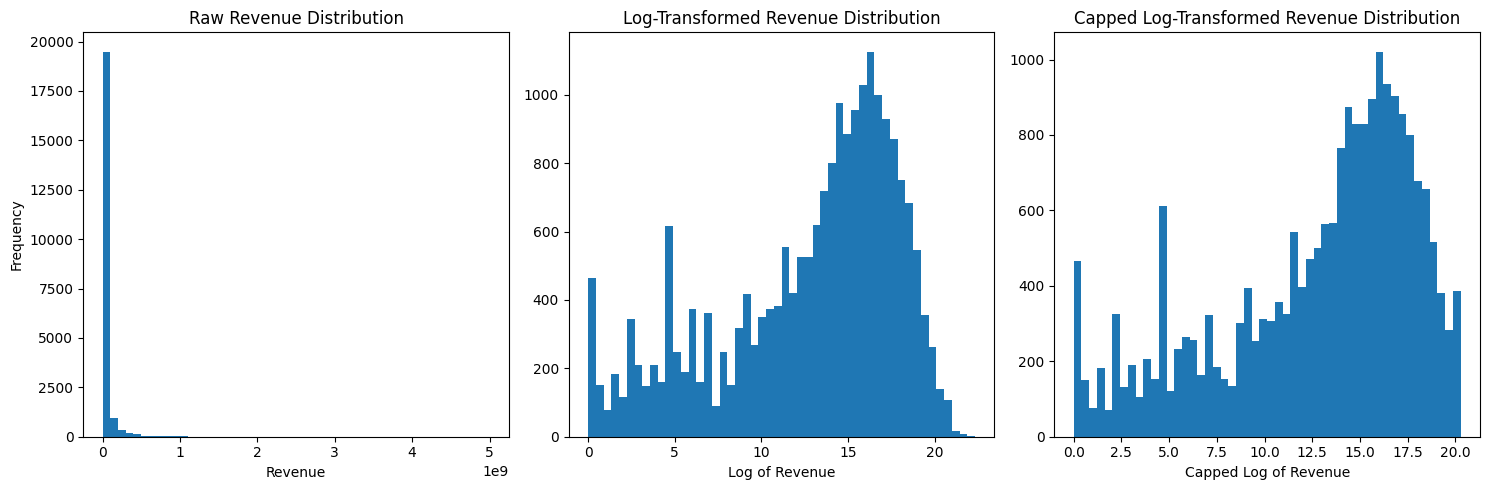

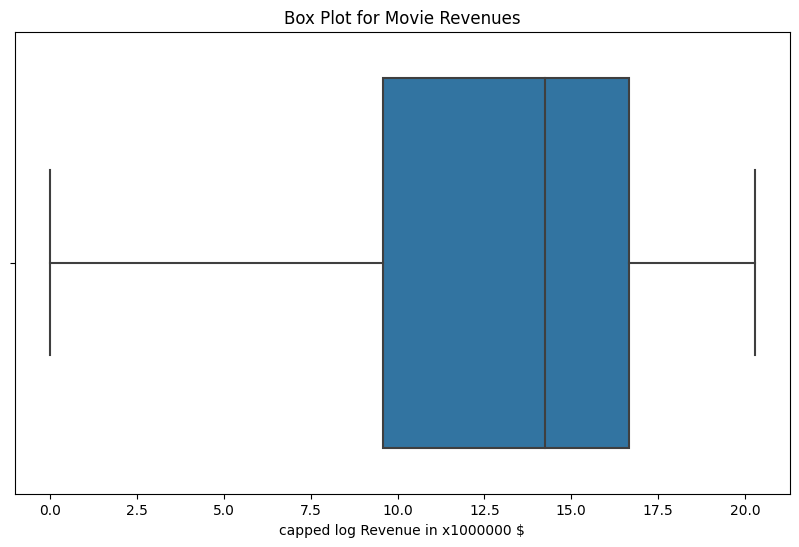

In [10]:
# Revenue Distribution Analysis

plt.figure(figsize=(15, 5))

# Raw Revenue
plt.subplot(1, 3, 1)
plt.hist(revenue_data['revenue'], bins=50)
plt.title('Raw Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')

# Log-Transformed Revenue
plt.subplot(1, 3, 2)
plt.hist(revenue_data['log_revenue'], bins=50)
plt.title('Log-Transformed Revenue Distribution')
plt.xlabel('Log of Revenue')

# Capped Log-Transformed Revenue
plt.subplot(1, 3, 3)
plt.hist(revenue_data['capped_log_revenue'], bins=50)
plt.title('Capped Log-Transformed Revenue Distribution')
plt.xlabel('Capped Log of Revenue')

plt.tight_layout()
plt.show()

# Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=revenue_data['capped_log_revenue'])
plt.title('Box Plot for Movie Revenues')
plt.xlabel('capped log Revenue in x1000000 $')
plt.show()


## 2. Budget vs. Revenue Analysis

Correlation coefficient between budget and revenue: 0.642478778222043


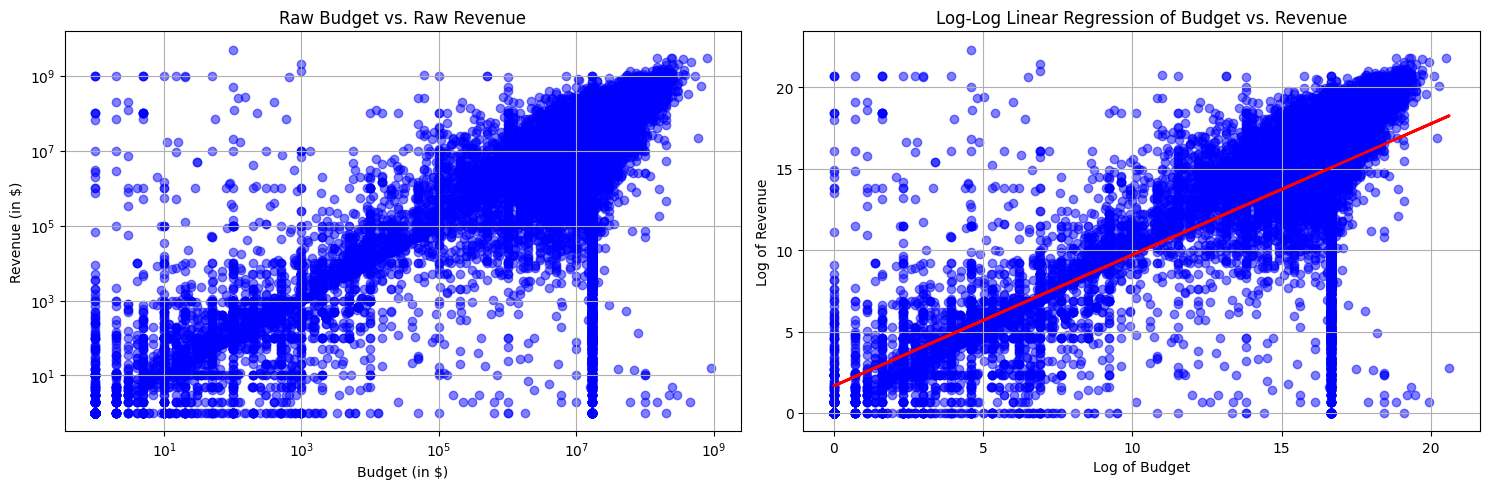

In [9]:
# Budget vs. Revenue Analysis 

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.scatter(revenue_data['budget'], revenue_data['revenue'], alpha=0.5, color='blue')
plt.title('Raw Budget vs. Raw Revenue')
plt.xlabel('Budget (in $)')
plt.ylabel('Revenue (in $)')
plt.grid(True)
plt.xscale('log')  # Using log scale for better visualization
plt.yscale('log')  # Log scale on y-axis

correlation = revenue_data['budget'].corr(revenue_data['revenue'])
print(f"Correlation coefficient between budget and revenue: {correlation}")

# Linear Regression
model = LinearRegression()
model.fit(revenue_data[['log_budget']], revenue_data['log_revenue'])  # X needs to be 2D array hence double brackets

# Plotting regression line
plt.subplot(1, 2, 2)
plt.scatter(revenue_data['log_budget'], revenue_data['log_revenue'], alpha=0.5, color='blue')
plt.plot(revenue_data['log_budget'], model.predict(revenue_data[['log_budget']]), color='red', linewidth=2)
plt.title('Log-Log Linear Regression of Budget vs. Revenue')
plt.xlabel('Log of Budget')
plt.ylabel('Log of Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()


## 3. Genre Popularity Over Time

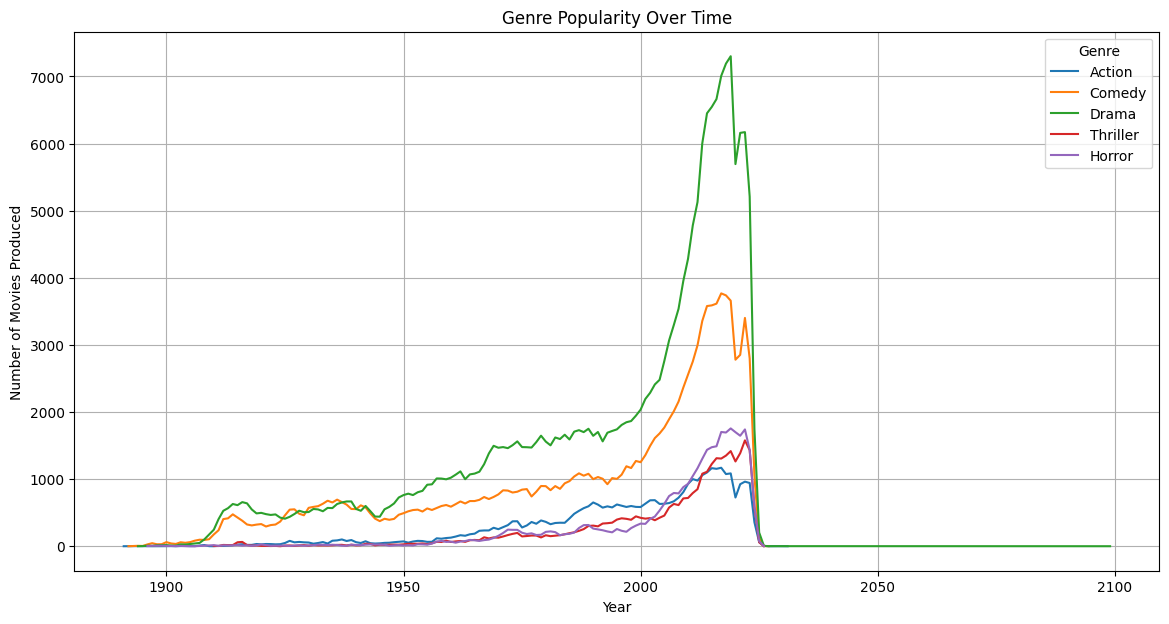

In [96]:
# Genre Popularity Over Time 

# Explode the 'genres' column into multiple rows
release_year_genre_data['genres'] = release_year_genre_data['genres'].str.split(',')
release_year_genre_data = release_year_genre_data.explode('genres')

# Group by year and genre, then count the number of movies
genre_popularity = release_year_genre_data.groupby(['year', 'genres']).size().reset_index(name='counts')

# Filter select genres for clarity in visualization
selected_genres = ['Action', 'Comedy', 'Drama', 'Thriller', 'Horror']
filtered_data = genre_popularity[genre_popularity['genres'].isin(selected_genres)]

plt.figure(figsize=(14, 7))
for genre in selected_genres:
    subset = filtered_data[filtered_data['genres'] == genre]
    plt.plot(subset['year'], subset['counts'], marker='', label=genre)

plt.title('Genre Popularity Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Movies Produced')
plt.legend(title='Genre')
plt.grid(True)
plt.show()

## 4. Impact of Ratings on Revenue

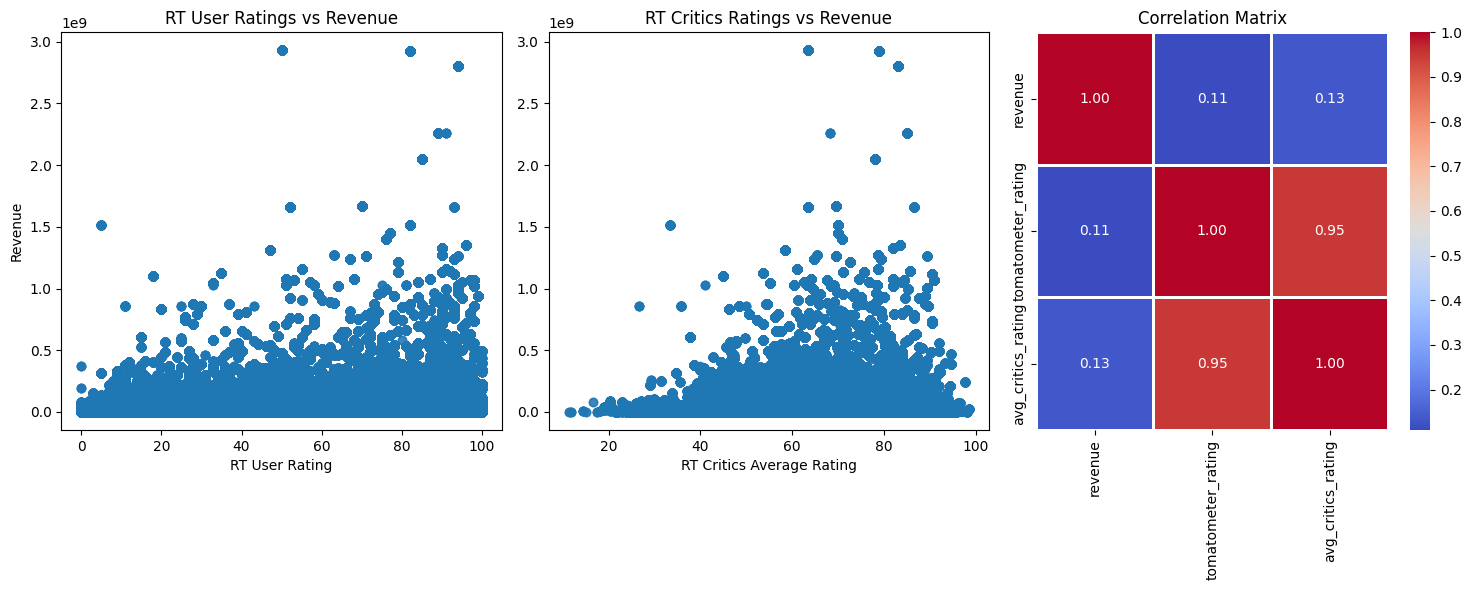

In [97]:
# Impact of Ratings on Revenue

plt.figure(figsize=(15, 6))

# Scatter plot for User Ratings vs Revenue
plt.subplot(1, 3, 1)
plt.scatter(merged_df['tomatometer_rating'], merged_df['revenue'], alpha=0.5)
plt.title('RT User Ratings vs Revenue')
plt.xlabel('RT User Rating')
plt.ylabel('Revenue')

# Scatter plot for Critics Ratings vs Revenue
plt.subplot(1, 3, 2)
plt.scatter(merged_df['avg_critics_rating'], merged_df['revenue'], alpha=0.5)
plt.title('RT Critics Ratings vs Revenue')
plt.xlabel('RT Critics Average Rating')

# Selecting relevant columns for the correlation matrix
correlation_matrix = merged_df[['revenue', 'tomatometer_rating', 'avg_critics_rating']].corr()

# Plotting the correlation matrix
plt.subplot(1, 3, 3)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

## 5. Skewness and Outliers in Key Metrics

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


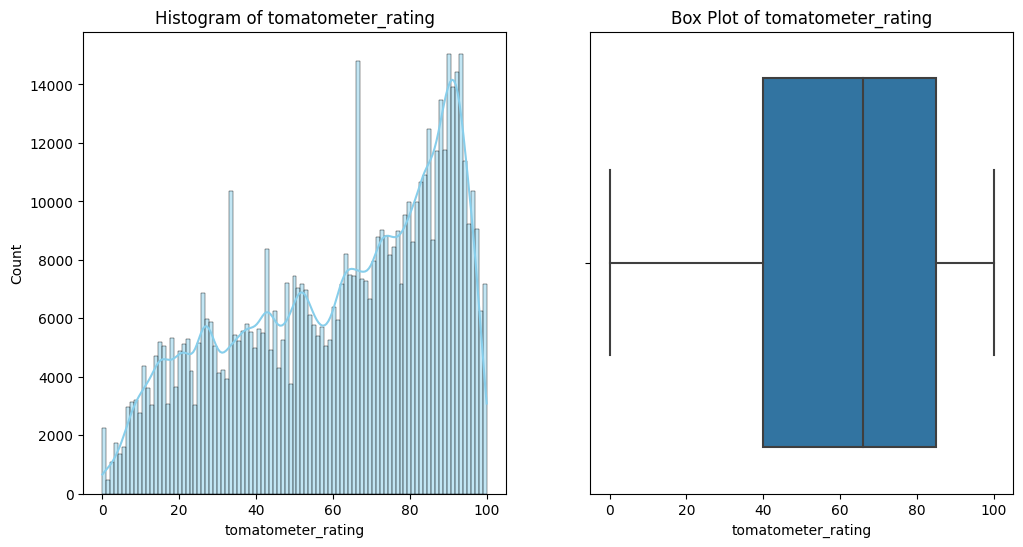

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


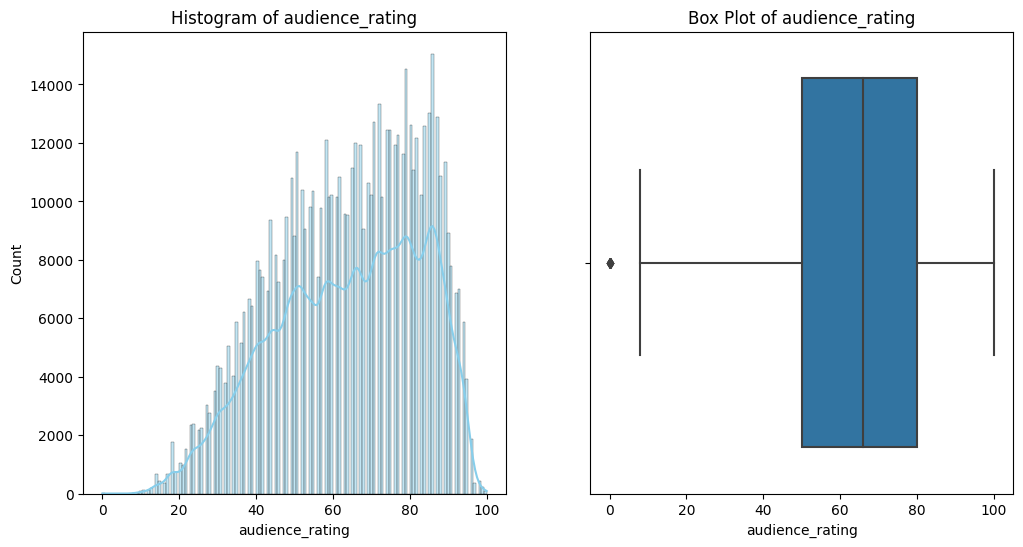

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


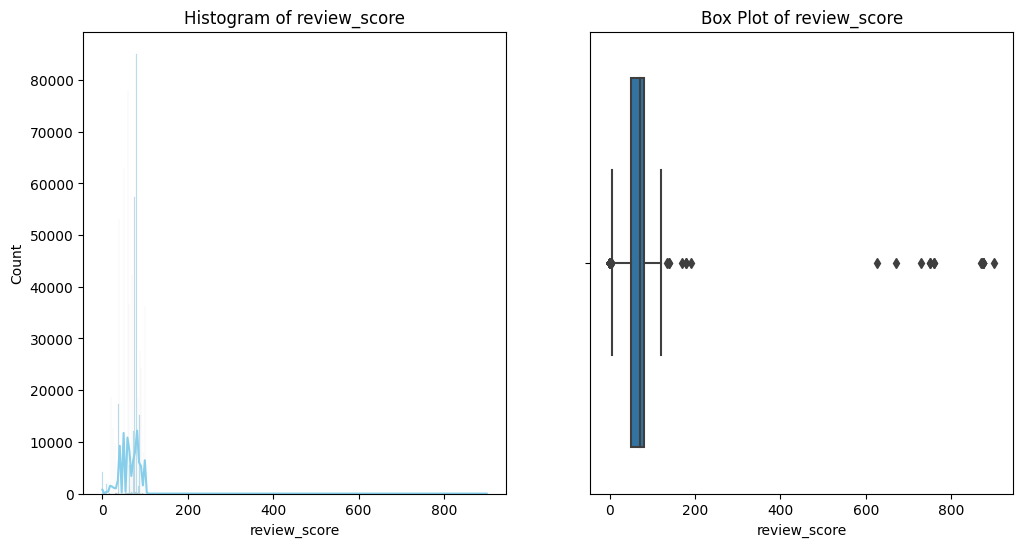

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


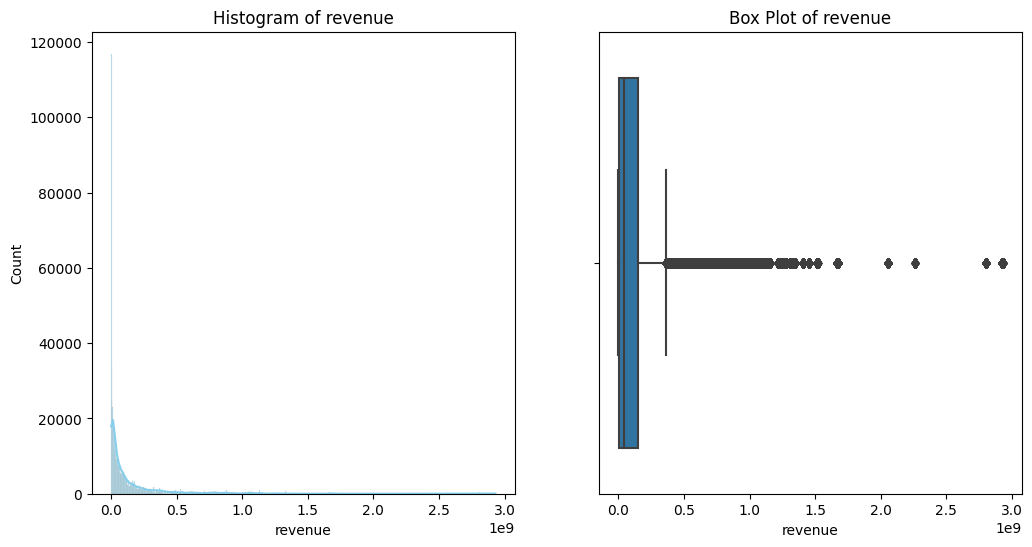

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


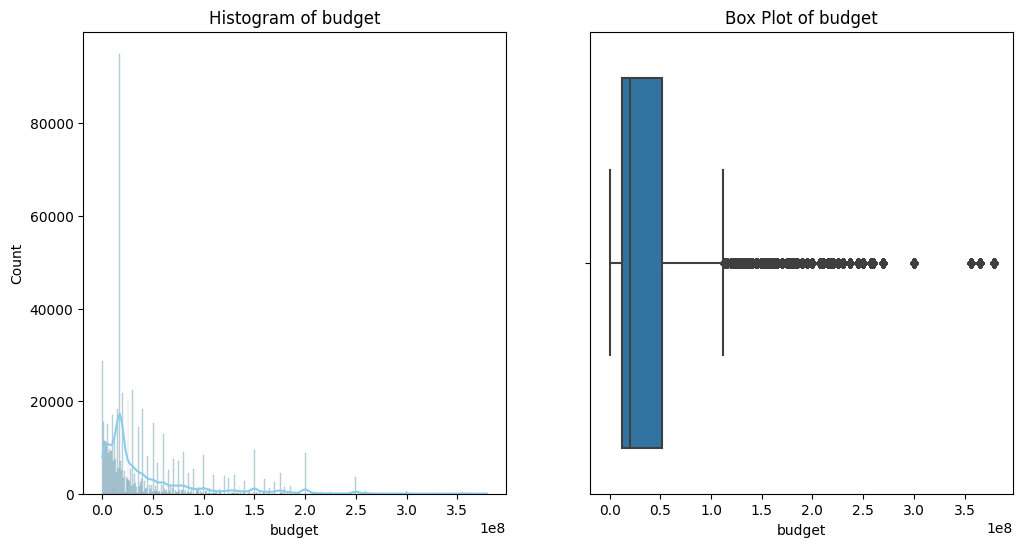

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


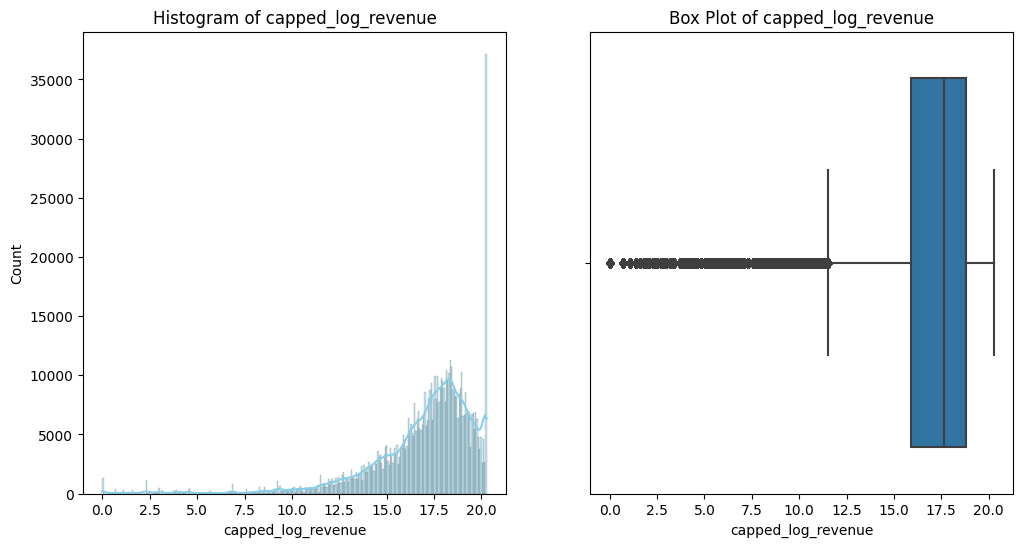

In [98]:
# Skewness and Outliers in Key Metrics

metrics = ['tomatometer_rating', 'audience_rating','review_score', 'revenue', 'budget', 'capped_log_revenue']
# Replace infinite values with NaN for the entire DataFrame before processing individual metrics
merged_df.replace([np.inf, -np.inf], np.nan, inplace=True)

for metric in metrics:
    # Convert data to numeric, coerce errors to NaN, and drop NaN values
    merged_df[metric] = pd.to_numeric(merged_df[metric], errors='coerce')
    merged_df.dropna(subset=[metric], inplace=True)  # Drop NaNs from specific metric column

    plt.figure(figsize=(12, 6))
    
    # Create histogram
    plt.subplot(1, 2, 1)
    sns.histplot(merged_df[metric], kde=True, color='skyblue')
    plt.title(f'Histogram of {metric}')
    
    # Create boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=merged_df[metric])
    plt.title(f'Box Plot of {metric}')
    
    plt.show()

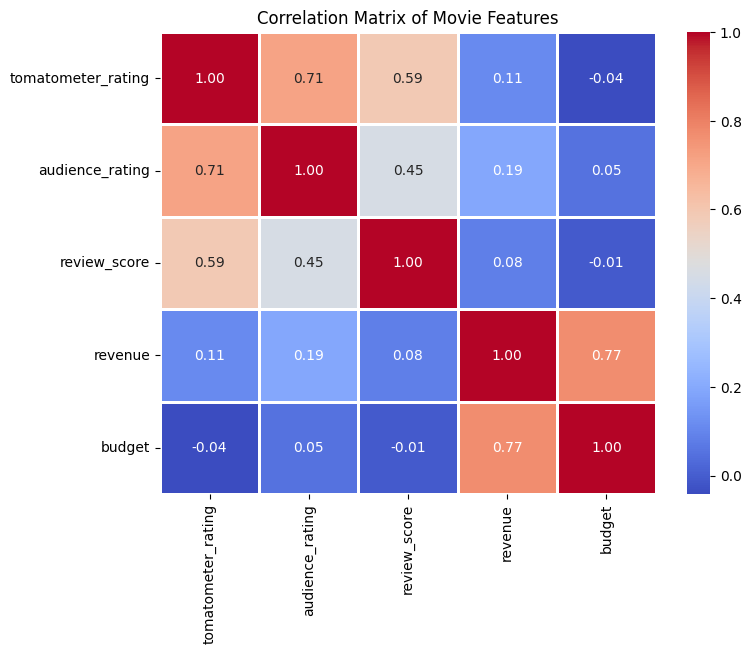

In [99]:
# Multicollinearity in Movie Features

cols = ['tomatometer_rating', 'audience_rating','review_score', 'revenue', 'budget']
merged_df.dropna(subset=cols, inplace=True)

corr_matrix = merged_df[cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title("Correlation Matrix of Movie Features")
plt.show()

In [101]:
print(revenue_data['release_date'].dtype)

object


## 6. Release Timing and Revenue Performance

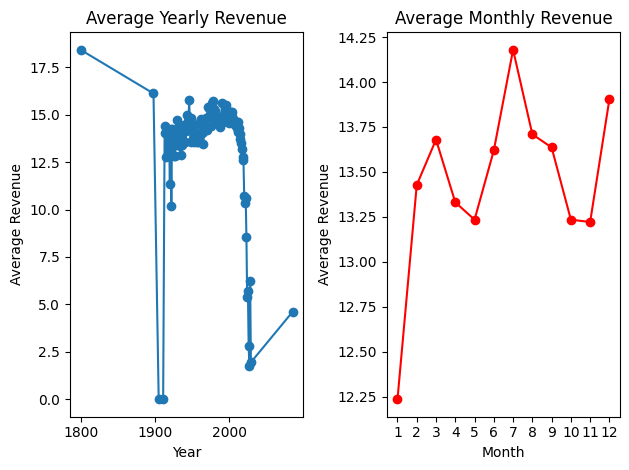

In [103]:
# Release Timing and Revenue Performance

revenue_data = revenue_data.dropna(subset=['release_date'])
revenue_data['year'] = revenue_data['release_date'].dt.year
revenue_data['month'] = revenue_data['release_date'].dt.month

# Group by month and calculate average revenue
monthly_revenue = revenue_data.groupby('month')['log_revenue'].mean().reset_index()

# Group by year and calculate average revenue
yearly_revenue = revenue_data.groupby('year')['log_revenue'].mean().reset_index()

# Yearly revenue trend
plt.subplot(1, 2, 1)
plt.plot(yearly_revenue['year'], yearly_revenue['log_revenue'], marker='o')
plt.title('Average Yearly Revenue')
plt.xlabel('Year')
plt.ylabel('Average Revenue')

# Monthly revenue trend
plt.subplot(1, 2, 2)
plt.plot(monthly_revenue['month'], monthly_revenue['log_revenue'], marker='o', color='red')
plt.title('Average Monthly Revenue')
plt.xlabel('Month')
plt.xticks(range(1, 13))  # Ensure all months are shown
plt.ylabel('Average Revenue x1000000 $')

plt.tight_layout()
plt.show()

# ------------------------Milestone 2-------------------------

# Feature Engineering

In [ ]:
# read the stored merged data frame
omdbc = pd.read_csv('../data/output.csv', low_memory=False)


In [6]:
# Helper Functions

def is_festive(month):
    if month in [1, 6, 7, 10, 11, 12]:
        return 'True'
    else:
        return 'False'

## A. Creating New Features

### 1. Time Based Feature

In [ ]:
revenue_data = omdbc.rename(columns={
    "year" : "release_year",
    "month" : "release_month"
})

revenue_data["is_festive_month"] = revenue_data["release_month"].apply(is_festive)
if "gross" in omdbc.columns:
    omdbc["log_gross"] = np.log1p(omdbc["gross"])
omdbc["log_budget"] = np.log1p(omdbc["budget"])


# Group by festive_month and calculate total revenue
omdbc = omdbc.groupby('is_festive_month')['log_gross'].sum().reset_index()
sns.barplot(data=omdbc, x='is_festive_month', y='revenue')
plt.xlabel('Festive Status')
plt.ylabel('Total Revenue')
plt.title('Revenue Comparison: Festive vs Non-Festive Months')
plt.show()

### 2. Interaction Features

In [ ]:
omdbc['budgetXvote'] = omdbc['vote'] * omdbc['log_budget']
correlation = omdbc[['log_gross', 'vote', 'budgetXgross', 'log_budget']].corr(method='pearson')
print(f"Correlation coefficient: {correlation}")
# fix outliers in popularity
plt.figure(figsize=(10, 5))
sns.regplot(x='budgetXpopularity', y='revenue', data=omdbc, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.title('Revenue vs. Popularity')
plt.xlabel('Popularity')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

### 3. Numerical Features

In [7]:
# budget based features
omdbc["budget_vote_ratio"] = omdbc["budget"] / (omdbc["votes"] + 1)
omdbc["budget_runtime_ratio"] = omdbc["budget"] / (omdbc["runtime"] + 1)
omdbc["budget_score_ratio"] = omdbc["log_budget"] / (omdbc["score"] + 1)
omdbc["budget_year_ratio"] = omdbc["log_budget"] / (omdbc["year"] - omdbc["year"].min() + 1)
omdbc["budget_per_minute"] = omdbc["budget"] / (omdbc["runtime"] + 1)

# votes based features
omdbc["vote_score_ratio"] = omdbc["votes"] / (omdbc["score"] + 1)
omdbc["votes_per_year"] = omdbc["votes"] / (omdbc["year"] - omdbc["year"].min() + 1)
omdbc["vote_year_ratio"] = omdbc["votes"] / (omdbc["year"] - omdbc["year"].min() + 1)

#score based features
omdbc["score_runtime_ratio"] = omdbc["score"] / (omdbc["runtime"] + 1)

### 4. Boolean features

In [8]:
# considering the year, budget, votes and score as features and values greater than 75 percentile as high values

year_q3 = omdbc['year'].quantile(0.75)
omdbc['is_recent'] = (omdbc['year'] >= year_q3).astype(int)

budget_q3 = omdbc['budget'].quantile(0.75)
omdbc['is_high_budget'] = (omdbc['budget'] >= budget_q3).astype(int)

votes_q3 = omdbc['votes'].quantile(0.75)
omdbc['is_high_votes'] = (omdbc['votes'] >= votes_q3).astype(int)

score_q3 = omdbc['score'].quantile(0.75)
omdbc['is_high_score'] = (omdbc['score'] >= score_q3).astype(int)

## B. Imputing newly generated features

In [9]:
# Data Preprocessing on newly created features
categorical_features = [
    "released",
    "writer",
    "rating",
    "name",
    "genre",
    "director",
    "star",
    "company",
]

for feature in categorical_features:
    omdbc[feature] = omdbc[feature].astype(str)
    le = LabelEncoder()
    omdbc[feature] = le.fit_transform(omdbc[feature])

numerical_features = [
    "runtime",
    "score",
    "year",
    "votes",
    "budget",
    "log_budget",
    "budget_vote_ratio",
    "budget_runtime_ratio",
    "budget_score_ratio",
    "vote_score_ratio",
    "budget_year_ratio",
    "vote_year_ratio",
    "score_runtime_ratio",
    "budget_per_minute",
    "votes_per_year",
    "is_recent",
    "is_high_budget",
    "is_high_votes",
    "is_high_score",
]

imputer = SimpleImputer(strategy="median")
omdbc[numerical_features] = imputer.fit_transform(omdbc[numerical_features])

scaler = StandardScaler()
omdbc[numerical_features] = scaler.fit_transform(omdbc[numerical_features])


## EDA on Engineered Features

### 1.	Summary Statistics

In [10]:
new_features = [
    'budget_year_ratio', 'vote_score_ratio', 
    'score_runtime_ratio', 'is_high_budget'
]

print(omdbc[new_features].describe())

       budget_year_ratio  vote_score_ratio  score_runtime_ratio  \
count        5421.000000      5.421000e+03         5.421000e+03   
mean            0.000000      4.194312e-17        -2.162692e-16   
std             1.000092      1.000092e+00         1.000092e+00   
min            -0.537091     -6.984052e-01        -3.948386e+00   
25%            -0.395247     -5.711594e-01        -6.375277e-01   
50%            -0.284112     -3.456316e-01        -5.090141e-02   
75%            -0.031592      1.331125e-01         6.082865e-01   
max             9.808728      1.097740e+01         5.197860e+00   

       is_high_budget  
count     5421.000000  
mean         0.000000  
std          1.000092  
min         -0.583244  
25%         -0.583244  
50%         -0.583244  
75%          1.714550  
max          1.714550  


### 2. Distribution of key features

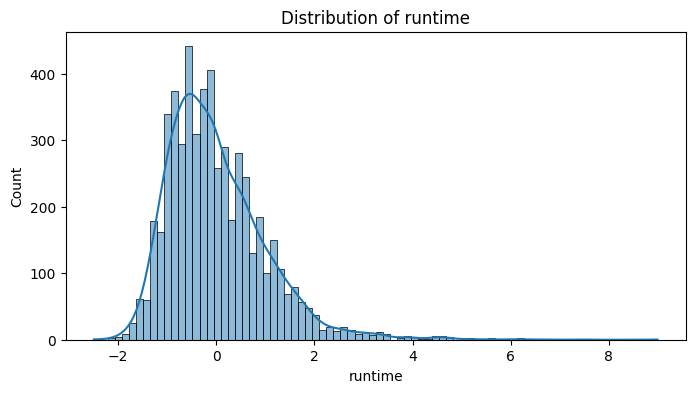

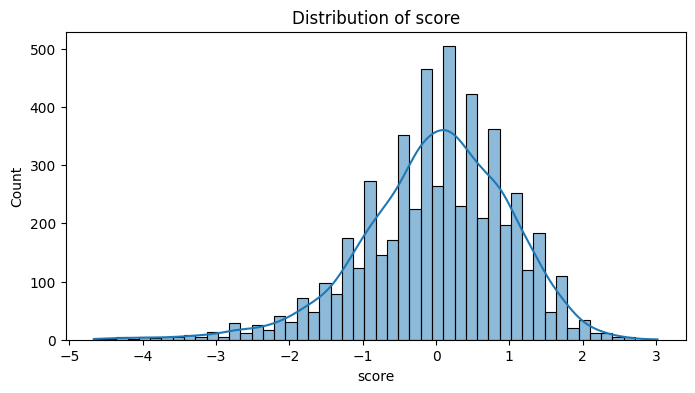

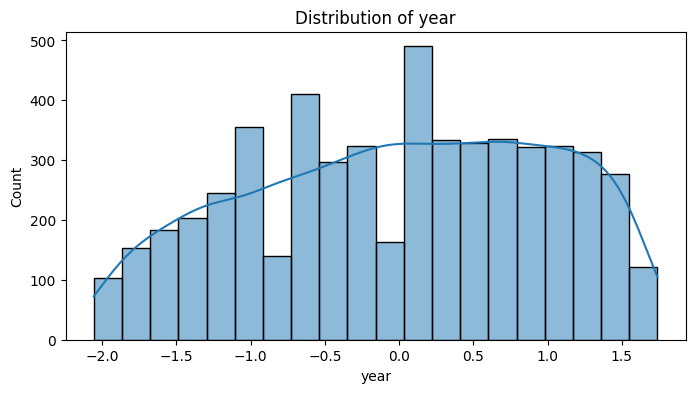

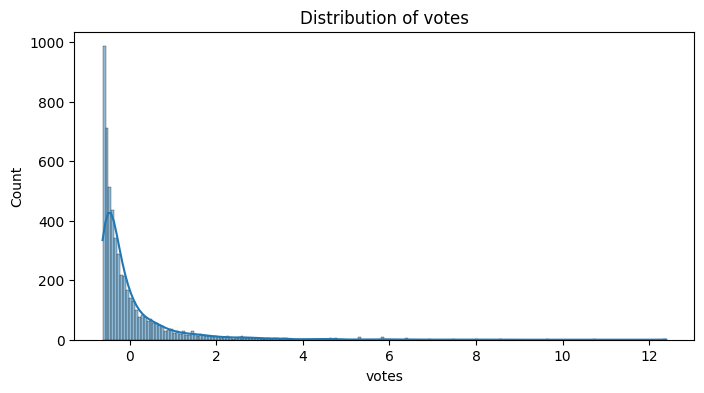

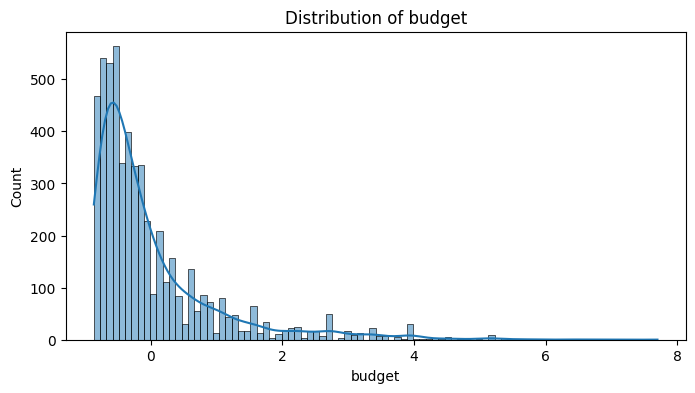

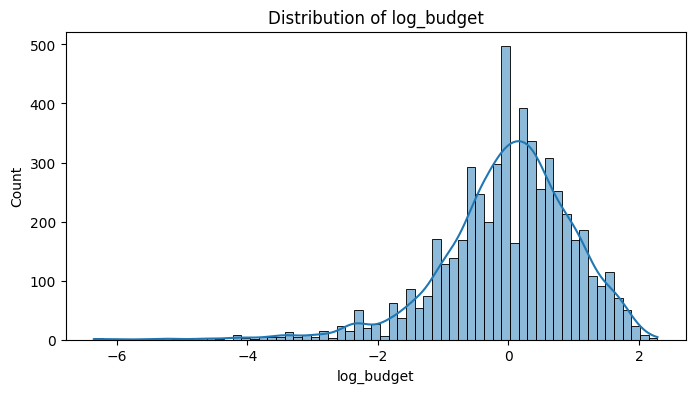

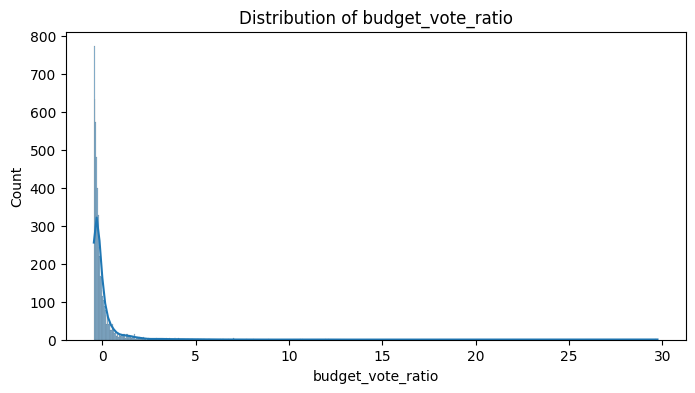

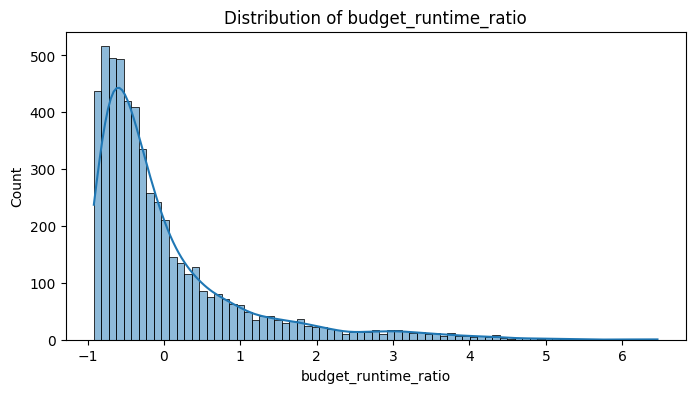

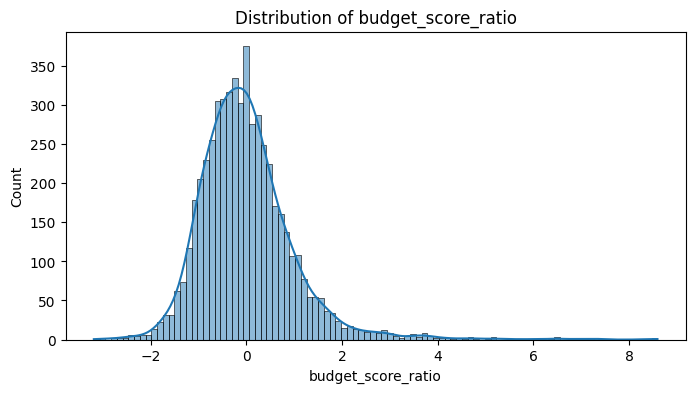

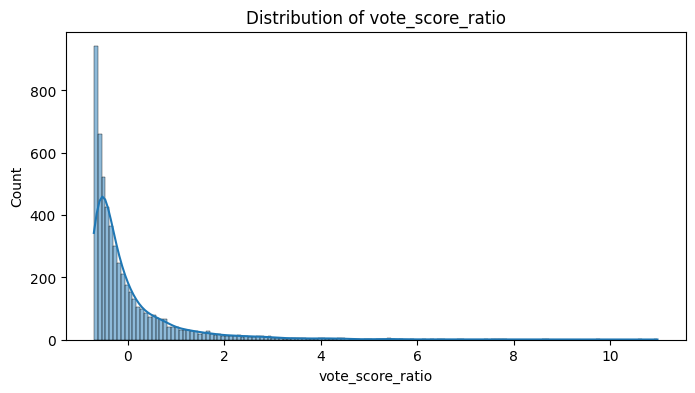

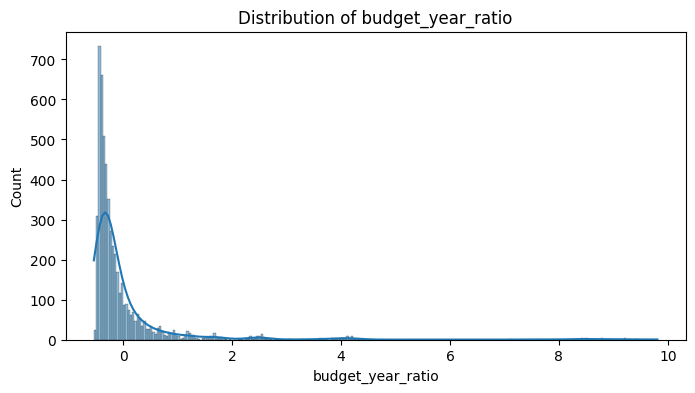

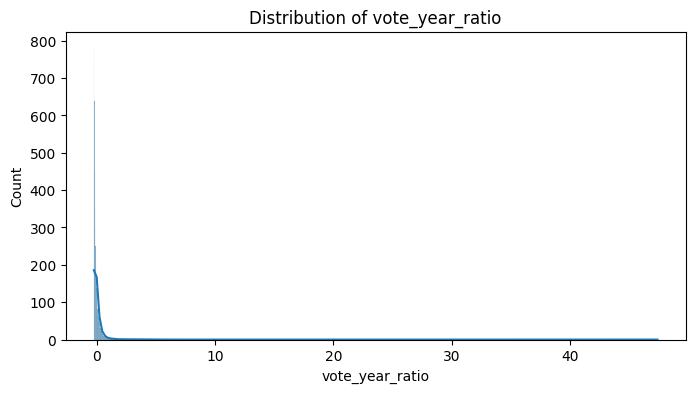

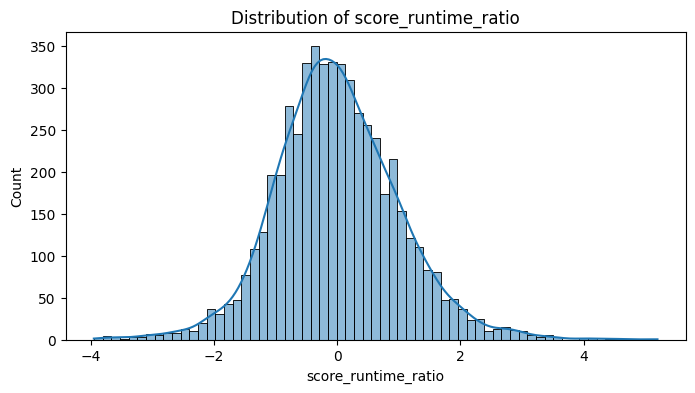

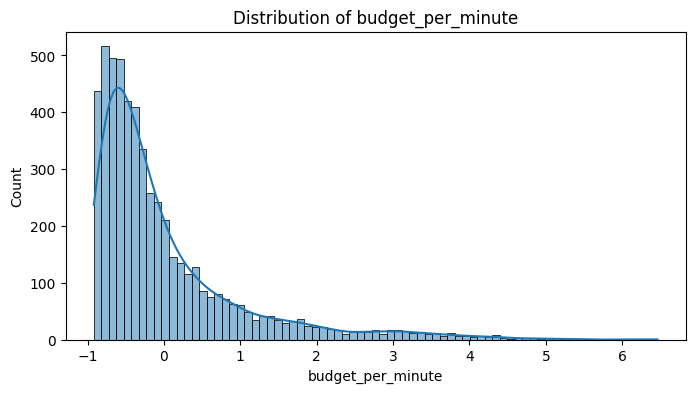

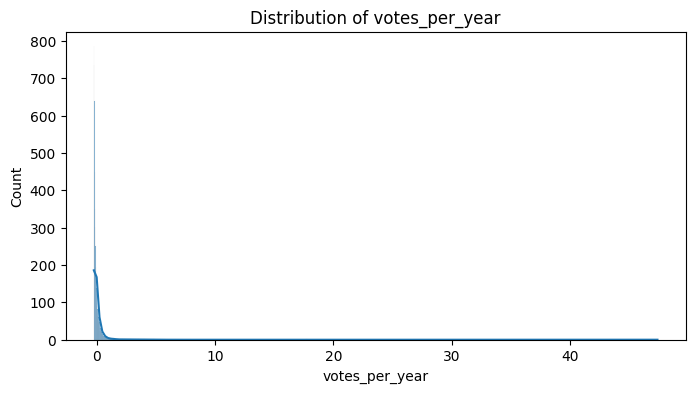

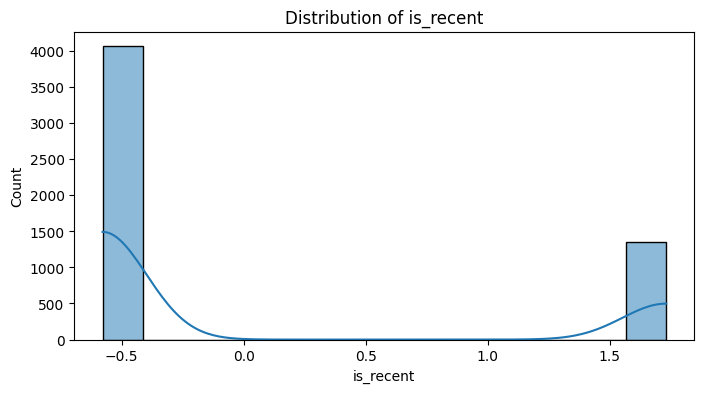

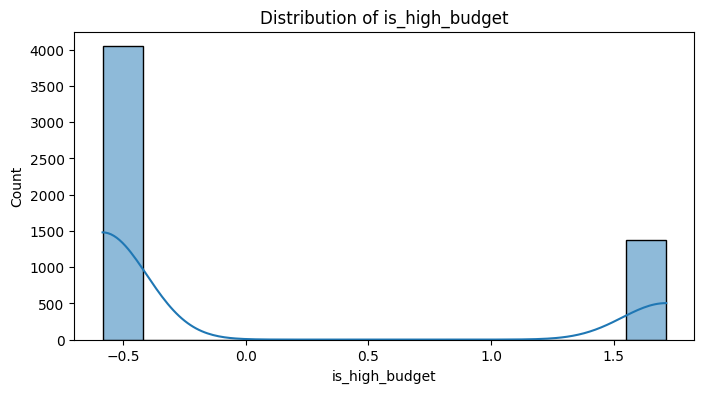

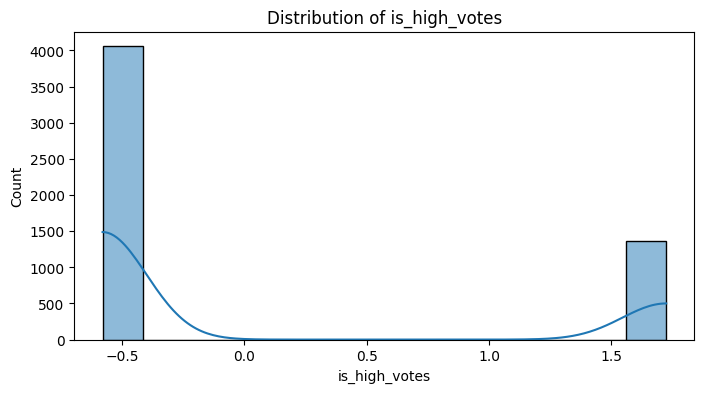

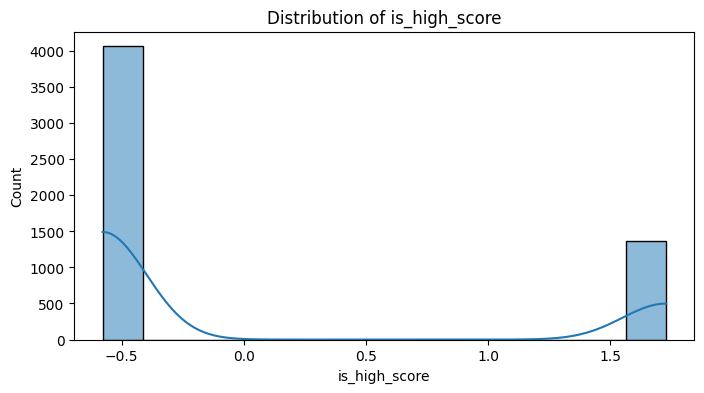

In [11]:
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(omdbc[feature], kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()

### 3. Boolean Features

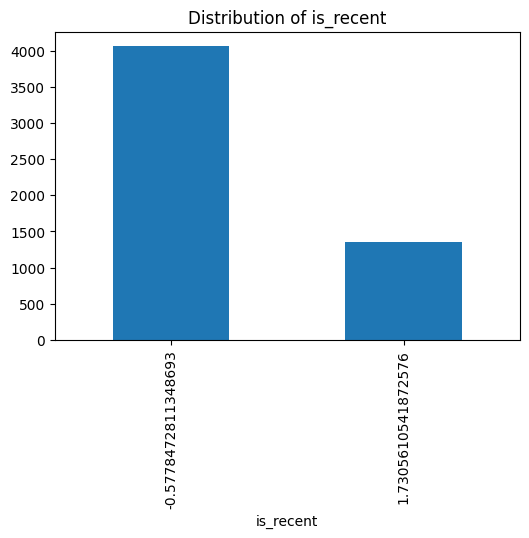

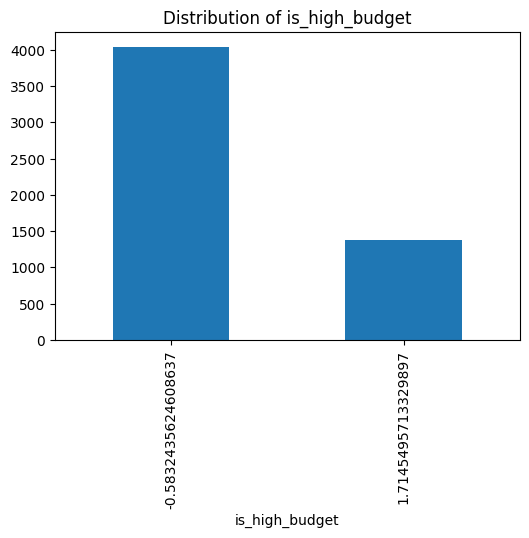

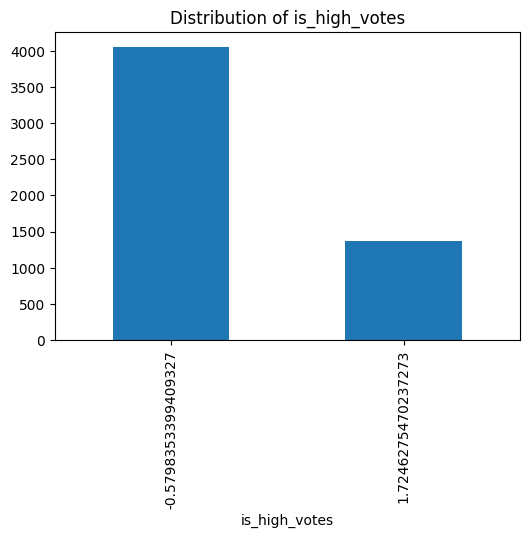

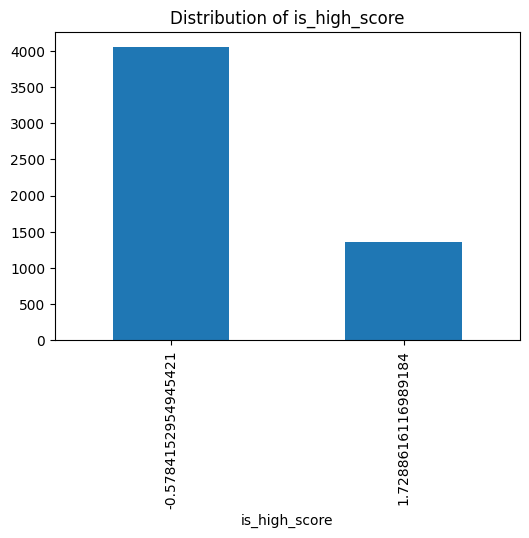

In [12]:
boolean_features = ["is_recent", "is_high_budget", "is_high_votes", "is_high_score"]

for feature in boolean_features:
    plt.figure(figsize=(6, 4))
    omdbc[feature].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {feature}")
    plt.show()

### 4. Correlation Analysis

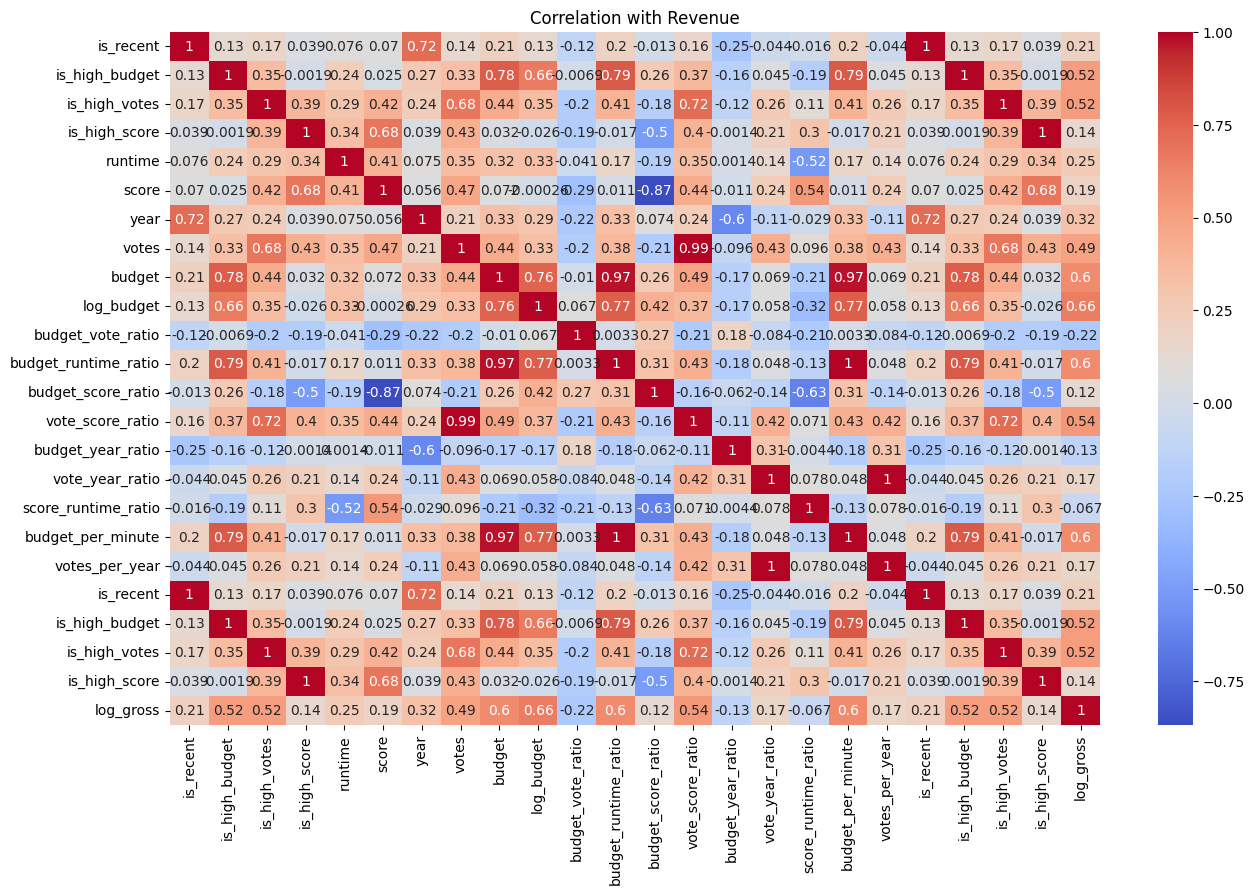

In [13]:
correlation_matrix = omdbc[boolean_features + numerical_features + ['log_gross']].corr()
plt.figure(figsize=(15, 9))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation with Revenue")
plt.show()

### 5. Outlier Detection

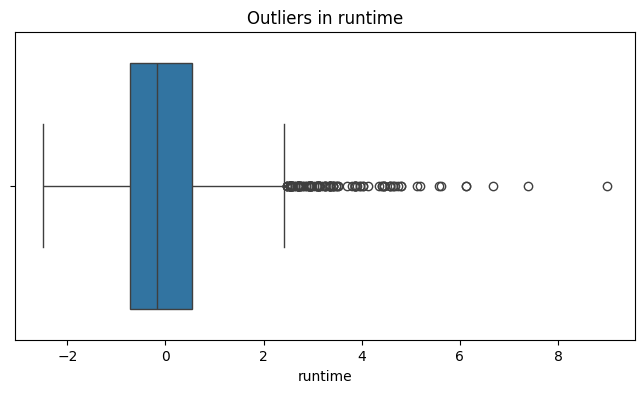

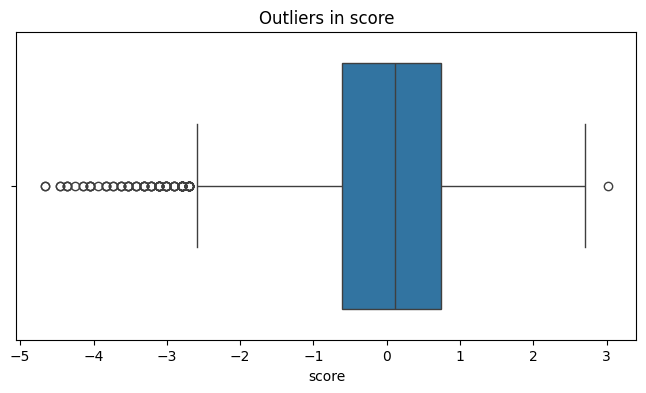

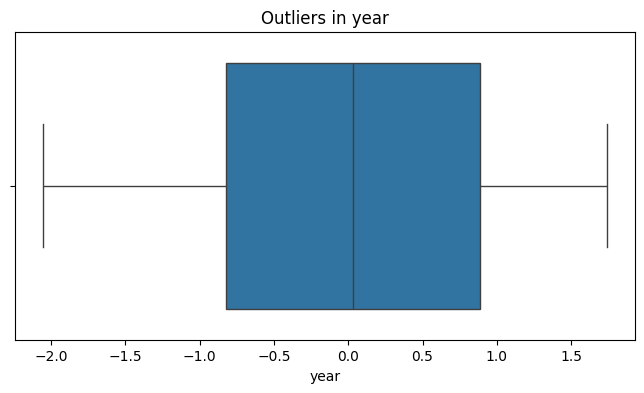

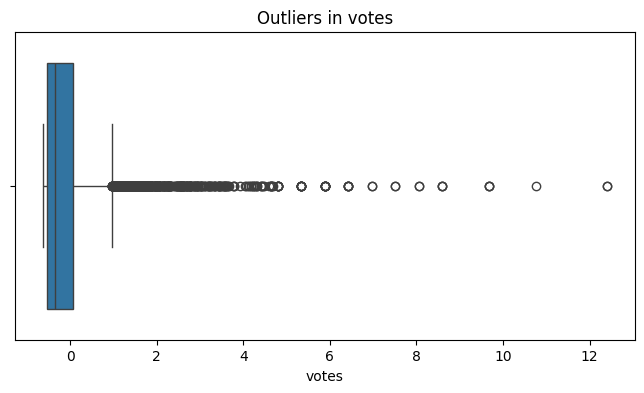

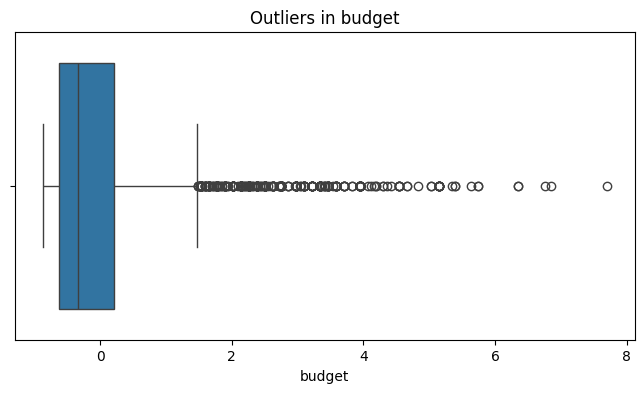

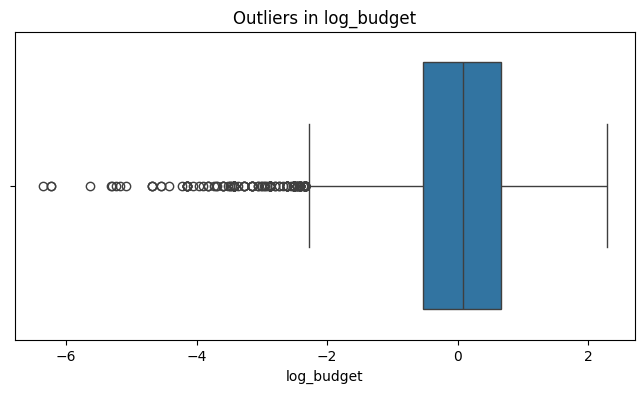

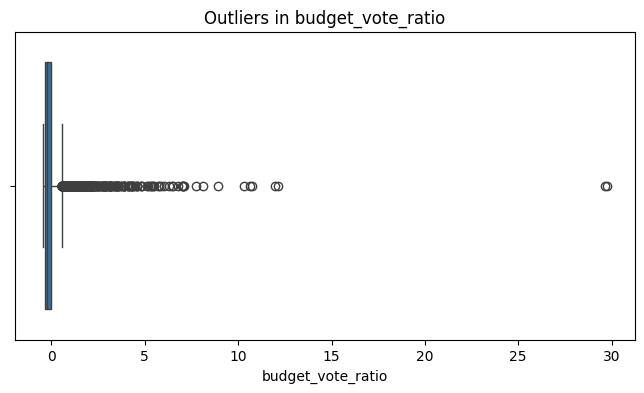

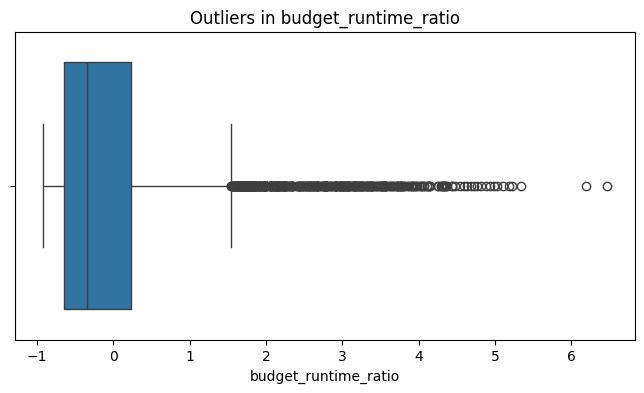

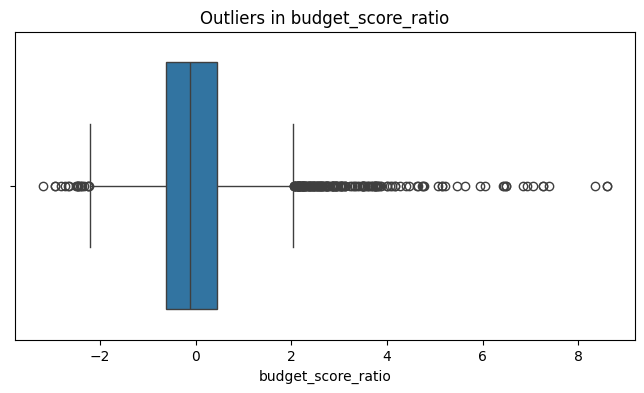

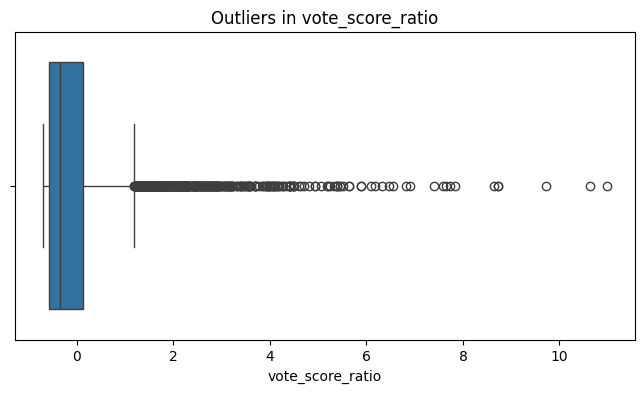

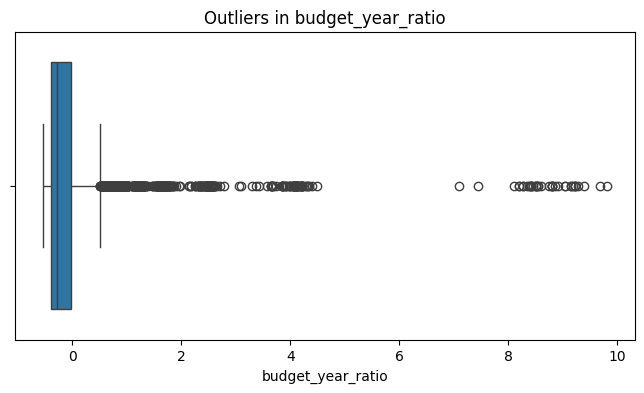

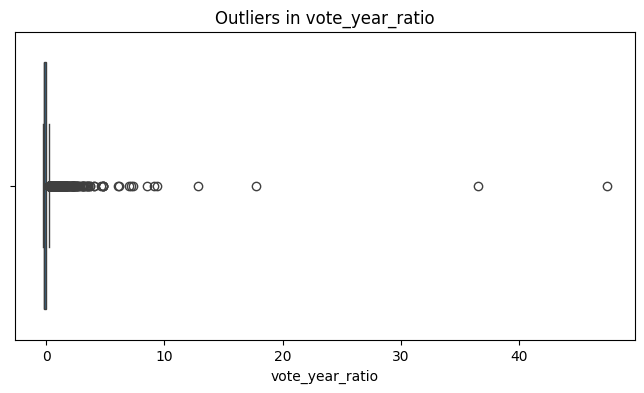

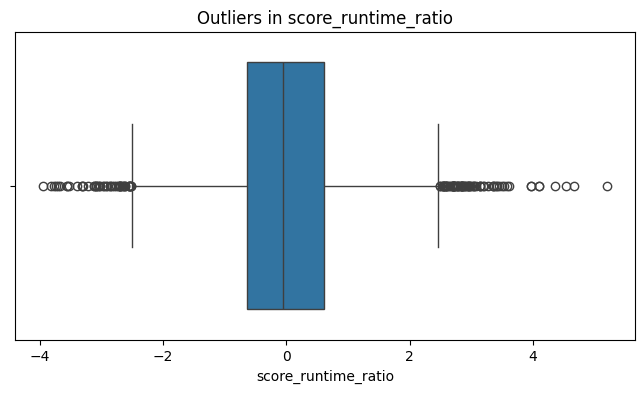

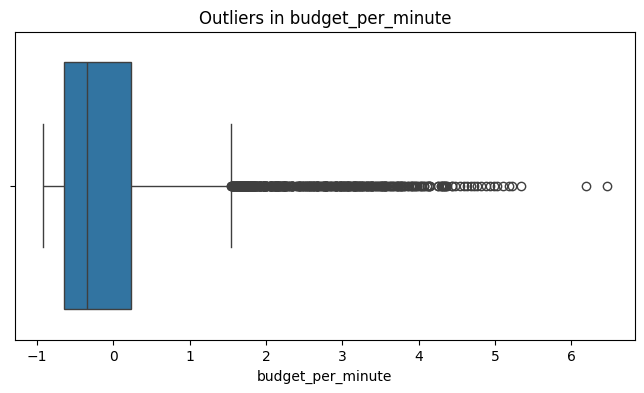

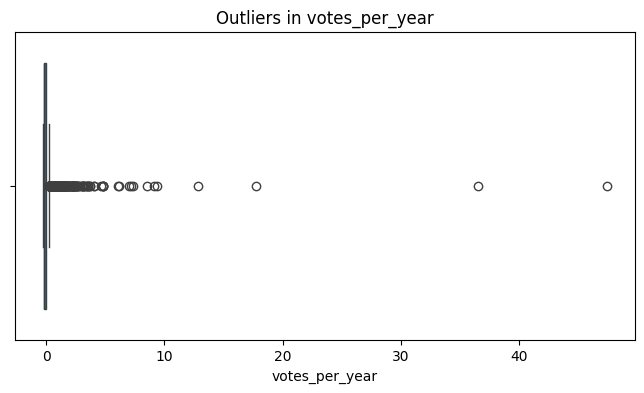

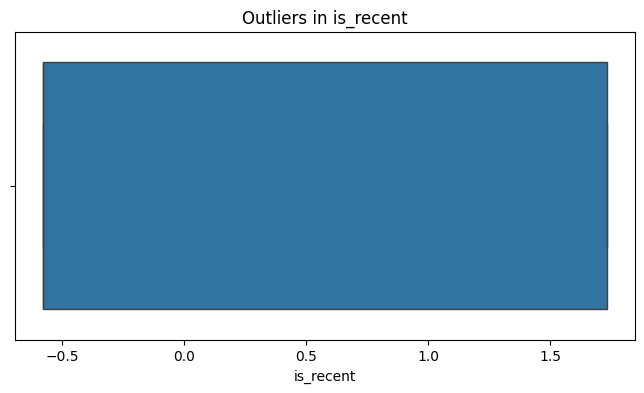

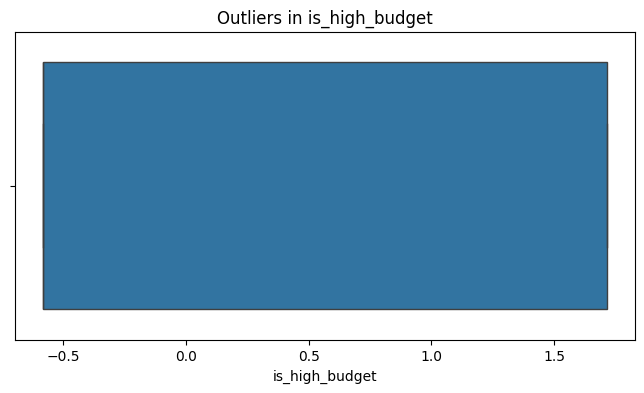

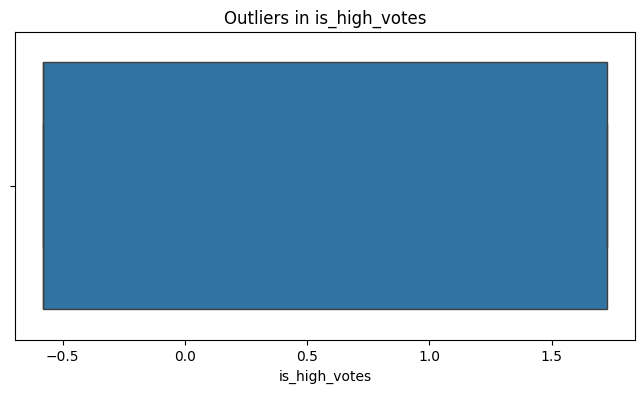

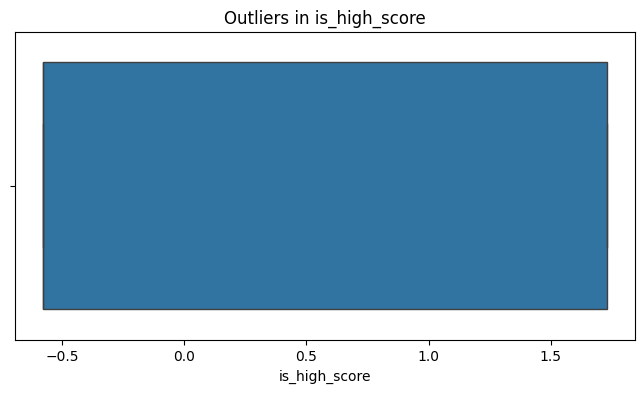

In [14]:
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=omdbc[feature])
    plt.title(f"Outliers in {feature}")
    plt.show()

# Feature Selection

## 1. Feature Score

In [19]:
# calculate feature scores using SelectKBest

target = omdbc["gross"]

# Process numerical features
numerical_features = omdbc[["year", "score", "votes", "budget", "runtime"]]

# Process categorical features
categorical_features = omdbc[
    [
    "released",
    "writer",
    "rating",
    "name",
    "genre",
    "director",
    "star",
    "company",
    ]
]

# One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_categorical = encoder.fit_transform(categorical_features)

# Prepare column names
numerical_features.columns = numerical_features.columns.astype(str)
categorical_feature_names = [
    str(col) for col in encoder.get_feature_names_out(categorical_features.columns)
]
feature_names = categorical_feature_names + list(numerical_features.columns)

# Create a DataFrame with encoded categorical features
encoded_categorical_df = pd.DataFrame(encoded_categorical, index=numerical_features.index)
encoded_categorical_df.columns = categorical_feature_names

# Combine features
features = pd.concat([encoded_categorical_df, numerical_features], axis=1)

# Check for any NaN values before proceeding
if features.isna().any().any():
    # Option 1: Drop rows with NaN values
    features = features.dropna()
    target = target.loc[features.index]  # Make sure target aligns with features
    
    # Option 2: Or impute missing values
    # from sklearn.impute import SimpleImputer
    # imputer = SimpleImputer(strategy='mean')  # or 'median', 'most_frequent'
    # features = pd.DataFrame(imputer.fit_transform(features), columns=features.columns)

# Apply feature selection
kbest = SelectKBest(score_func=f_regression, k="all")
kbest.fit(features, target)

# Create and output feature scores
feature_scores = pd.DataFrame({"Feature": feature_names, "Score": kbest.scores_})
print(feature_scores)
feature_scores.to_csv("../features/feature_scores.txt", index=False)

          Feature        Score
0      released_0     0.302600
1      released_1     0.303595
2      released_2     0.301070
3      released_3     0.298351
4      released_4     0.302923
...           ...          ...
16509        year   440.975532
16510       score   282.397728
16511       votes  3292.085413
16512      budget  6569.008340
16513     runtime   446.121279

[16514 rows x 2 columns]


## 2. Significant Features

In [20]:
significant_features = feature_scores[feature_scores["Score"] > 100]
significant_features = significant_features.sort_values(by="Score", ascending=False)

# Save significant features to a CSV file
significant_features.to_csv("../features/significant_features.txt", index=False)

print(significant_features)

            Feature        Score
16512        budget  6569.008340
16511         votes  3292.085413
16017   company_983   496.764152
16513       runtime   446.121279
16509          year   440.975532
5771       rating_6   337.959444
16510         score   282.397728
11113       genre_2   276.657909
11111       genre_0   239.210623
11231  director_105   238.515051
6161       name_386   223.478659
6163       name_388   215.130688
137    released_137   215.130688
3073     writer_513   199.157551
5770       rating_5   194.402250
16457  company_1423   172.259012
14659     star_1470   151.485500
10684     name_4909   128.491127
11911  director_785   127.387274
13545      star_356   120.605232
11115       genre_4   116.786195
9418      name_3643   112.494479
15979   company_945   110.297606
6164       name_389   110.037192
3823    writer_1263   108.337247
527    released_527   108.046077
16168  company_1134   107.263914
13482      star_293   105.223686
13568      star_379   102.613119


## 3. Correlation Matrix

In [21]:
correlation_matrix = omdbc[["year", "score", "votes", "budget", "runtime","gross"]].corr()
print(correlation_matrix)

             year     score     votes    budget   runtime     gross
year     1.000000  0.056386  0.206021  0.327722  0.075077  0.274321
score    0.056386  1.000000  0.474256  0.072001  0.414068  0.222556
votes    0.206021  0.474256  1.000000  0.439675  0.352303  0.614751
budget   0.327722  0.072001  0.439675  1.000000  0.318695  0.740247
runtime  0.075077  0.414068  0.352303  0.318695  1.000000  0.275796
gross    0.274321  0.222556  0.614751  0.740247  0.275796  1.000000


# Data Modeling

## Helper Functions

In [35]:
def preprocess_data(df, target_column="gross"):
    """
    Comprehensive data preprocessing and feature engineering pipeline.
    
    Args:
        df: Raw input DataFrame
        target_column: Name of target variable column
        
    Returns:
        Processed DataFrame ready for modeling
    """
    df = df.copy()
    
    # 1. Log Transformations for skewed numerical features
    df = apply_log_transforms(df, target_column)
    
    # 2. Feature Engineering
    df = create_interaction_features(df)
    df = create_ratio_features(df)
    df = create_quantile_flags(df)
    
    # 3. Categorical Feature Encoding
    df = encode_categorical_features(df)
    
    # 4. Numerical Feature Processing
    df = process_numerical_features(df)
    
    # 5. Final Cleanup
    df = drop_redundant_features(df, target_column)
    
    return df

def apply_log_transforms(df, target_column):
    """Apply logarithmic transformations to monetary and count variables"""
    if target_column in df.columns:
        df["log_gross"] = np.log1p(df[target_column])
    
    # Budget is present in all cases
    df["log_budget"] = np.log1p(df["budget"])
    
    return df

def create_interaction_features(df):
    """Create interaction features between key variables"""
    # Time-based interactions
    year_offset = df["year"] - df["year"].min() + 1
    df["budget_year_interaction"] = df["log_budget"] / year_offset
    df["votes_year_interaction"] = df["votes"] / year_offset
    
    # Content-based interactions
    df["score_runtime_ratio"] = df["score"] / (df["runtime"] + 1)
    df["budget_per_minute"] = df["budget"] / (df["runtime"] + 1)
    df["votes_per_year"] = df["votes"] / year_offset
    
    return df

def create_ratio_features(df):
    """Create ratio features between important variables"""
    # Budget ratios
    df["budget_vote_ratio"] = df["budget"] / (df["votes"] + 1)
    df["budget_runtime_ratio"] = df["budget"] / (df["runtime"] + 1)
    df["budget_score_ratio"] = df["log_budget"] / (df["score"] + 1)
    
    # Vote and score ratios
    df["vote_score_ratio"] = df["votes"] / (df["score"] + 1)
    
    return df

def create_quantile_flags(df):
    """Create binary flags based on quantile thresholds"""
    # Temporal flag
    df["is_recent"] = (df["year"] >= df["year"].quantile(0.75)).astype(int)
    
    # Budget flags
    df["is_high_budget"] = (df["log_budget"] >= df["log_budget"].quantile(0.75)).astype(int)
    
    # Engagement flags
    df["is_high_votes"] = (df["votes"] >= df["votes"].quantile(0.75)).astype(int)
    df["is_high_score"] = (df["score"] >= df["score"].quantile(0.75)).astype(int)
    
    return df

def encode_categorical_features(df):
    """Encode categorical features using label encoding"""
    categorical_features = [
        "released", "writer", "rating", "name", 
        "genre", "director", "star", "country", "company"
    ]
    
    # Only encode columns that exist in DataFrame
    existing_cats = [col for col in categorical_features if col in df.columns]
    
    for feature in existing_cats:
        le = LabelEncoder()
        df[feature] = le.fit_transform(df[feature].astype(str))
        
    return df

def process_numerical_features(df):
    """Handle missing values and scale numerical features"""
    numerical_features = [
        "runtime", "score", "year", "votes", "log_budget",
        "budget_vote_ratio", "budget_runtime_ratio", "budget_score_ratio",
        "vote_score_ratio", "budget_year_interaction", "votes_year_interaction",
        "score_runtime_ratio", "budget_per_minute", "votes_per_year",
        "is_recent", "is_high_budget", "is_high_votes", "is_high_score"
    ]
    
    # Only process columns that exist in DataFrame
    existing_nums = [col for col in numerical_features if col in df.columns]
    
    # Median imputation
    imputer = SimpleImputer(strategy="median")
    df[existing_nums] = imputer.fit_transform(df[existing_nums])
    
    # Standard scaling (excluding binary flags)
    binary_flags = [col for col in existing_nums if col.startswith('is_')]
    scaling_features = [col for col in existing_nums if col not in binary_flags]
    
    if scaling_features:
        scaler = StandardScaler()
        df[scaling_features] = scaler.fit_transform(df[scaling_features])
    
    return df

def drop_redundant_features(df, target_column):
    """Remove redundant features after processing"""
    columns_to_drop = ["budget"]
    if target_column in df.columns:
        columns_to_drop.append(target_column)
    
    # Only drop columns that exist
    existing_drops = [col for col in columns_to_drop if col in df.columns]
    
    return df.drop(existing_drops, axis=1)

def prepare_features(df, target_column="gross"):
    """
    Prepare feature matrix (X) and target vector (y) from raw DataFrame.
    
    Args:
        df: Raw input DataFrame
        target_column: Name of target variable column
        
    Returns:
        X: Feature matrix
        y: Target vector (None if target column not present)
    """
    processed_df = preprocess_data(df, target_column)
    
    if "log_gross" in processed_df.columns:
        y = processed_df["log_gross"]
        X = processed_df.drop("log_gross", axis=1)
    else:
        y = None
        X = processed_df
    
    return X, y

## 1. Linear Regression PCA


Training Metrics:
  R² score: 0.2071
  MSE: 2.7720
  MSLE: 0.0098
  MAPE: 2784.34%

Test Metrics:
  R² score: 0.1869
  MSE: 3.1909
  MSLE: 0.0115
  MAPE: 1470.14%


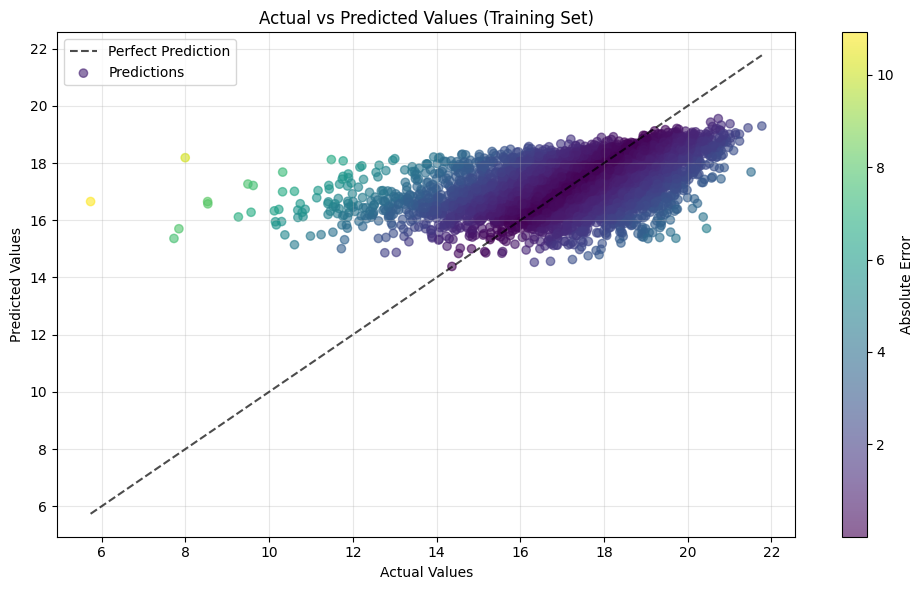

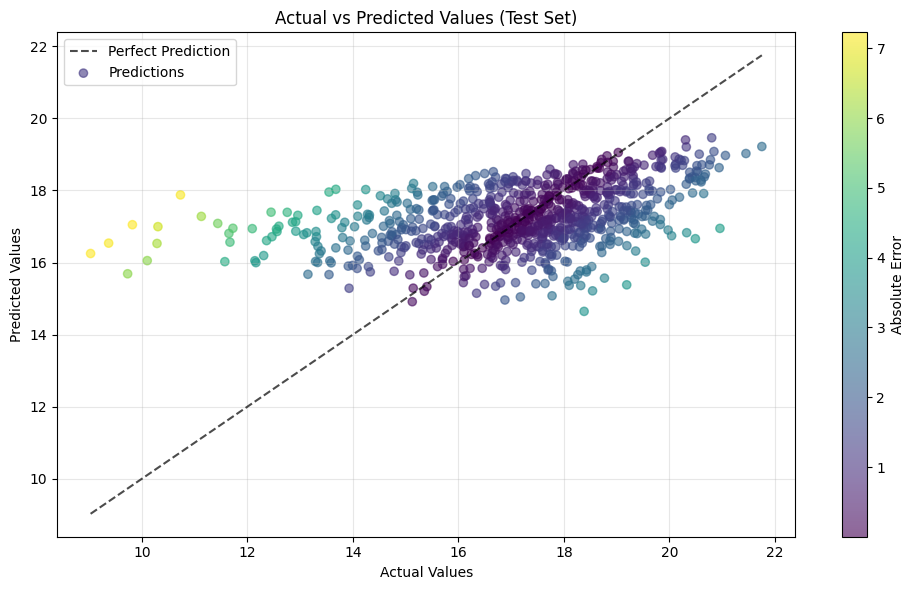

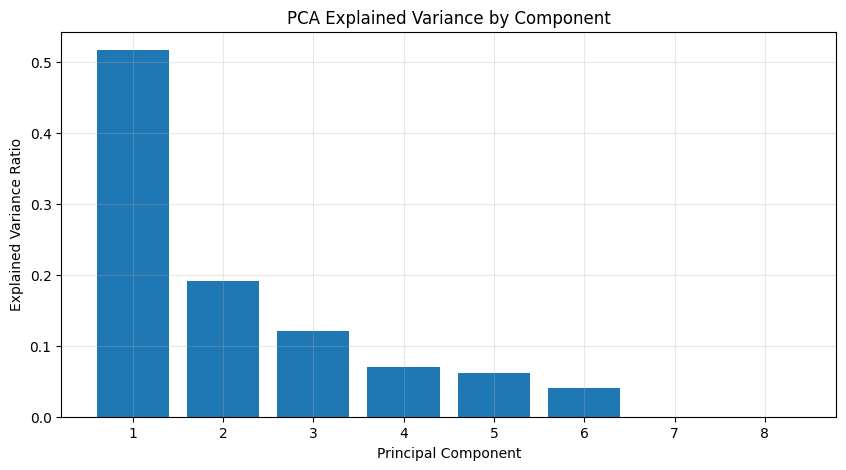

In [36]:
def calculate_metrics(y_true, y_pred):
    """
    Calculate regression performance metrics.
    
    Args:
        y_true: Array of true target values
        y_pred: Array of predicted values
        
    Returns:
        Tuple of metrics (r2, mse, msle, mape)
    """
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    msle = mean_squared_log_error(y_true, y_pred)
    
    # Calculate Mean Absolute Percentage Error (MAPE)
    # Using exp() if working with log-transformed targets
    mape = np.mean(np.abs((np.exp(y_true) - np.exp(y_pred)) / np.exp(y_true))) * 100
    
    return r2, mse, msle, mape

def print_metrics(metrics, label="Metrics"):
    """
    Print formatted evaluation metrics.
    
    Args:
        metrics: Tuple of (r2, mse, msle, mape)
        label: Header for the metrics section
    """
    r2, mse, msle, mape = metrics
    print(f"\n{label}:")
    print(f"  R² score: {r2:.4f}")  # Coefficient of determination
    print(f"  MSE: {mse:.4f}")      # Mean Squared Error
    print(f"  MSLE: {msle:.4f}")    # Mean Squared Logarithmic Error
    print(f"  MAPE: {mape:.2f}%")   # Mean Absolute Percentage Error

def plot_actual_vs_predicted(y_true, y_pred, title_suffix=""):
    """
    Create an enhanced actual vs predicted values plot with regression line.
    
    Args:
        y_true: Array of true values
        y_pred: Array of predicted values
        title_suffix: Additional text for plot title
    """
    plt.figure(figsize=(10, 6))
    
    # Calculate regression line for perfect predictions
    max_val = max(np.max(y_true), np.max(y_pred))
    min_val = min(np.min(y_true), np.min(y_pred))
    perfect_line = np.linspace(min_val, max_val, 100)
    
    # Plot perfect prediction line
    plt.plot(perfect_line, perfect_line, 'k--', 
             label='Perfect Prediction', alpha=0.7)
    
    # Plot actual vs predicted points
    plt.scatter(y_true, y_pred, alpha=0.6, 
                c=np.abs(y_true - y_pred), 
                cmap='viridis', label='Predictions')
    
    plt.colorbar(label='Absolute Error')
    plt.title(f"Actual vs Predicted Values {title_suffix}")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution
if __name__ == "__main__":
    # Load and prepare data (assuming df is defined elsewhere)
    X, y = prepare_features(omdbc)
    
    # Split data into training and test sets (85/15 split)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42
    )
    
    # Apply PCA for dimensionality reduction
    pca = PCA(n_components=8)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    # Initialize and train linear regression model
    model = LinearRegression()
    model.fit(X_train_pca, y_train)
    
    # Generate predictions
    train_predictions = model.predict(X_train_pca)
    test_predictions = model.predict(X_test_pca)
    
    # Calculate and display metrics
    train_metrics = calculate_metrics(y_train, train_predictions)
    test_metrics = calculate_metrics(y_test, test_predictions)
    
    print_metrics(train_metrics, "Training Metrics")
    print_metrics(test_metrics, "Test Metrics")
    
    # Create enhanced visualization
    plot_actual_vs_predicted(y_train, train_predictions, "(Training Set)")
    plot_actual_vs_predicted(y_test, test_predictions, "(Test Set)")
    
    # Optional: Plot explained variance ratio from PCA
    plt.figure(figsize=(10, 5))
    plt.bar(range(1, 9), pca.explained_variance_ratio_)
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance Ratio')
    plt.title('PCA Explained Variance by Component')
    plt.xticks(range(1, 9))
    plt.grid(True, alpha=0.3)
    plt.show()

## 2. Linear Regression


╔═══════════════════════════════════╗
║       Training Set Metrics        ║
╠═══════════════╦═══════════════════╣
║ R² Score      ║            0.6210 ║
║ MSE           ║            1.3251 ║
║ RMSE          ║            1.1511 ║
║ MSLE          ║            0.0052 ║
║ MAPE          ║          1047.33% ║
║ Max Error     ║           10.2269 ║
╚═══════════════╩═══════════════════╝

╔═══════════════════════════════════╗
║         Test Set Metrics          ║
╠═══════════════╦═══════════════════╣
║ R² Score      ║            0.6481 ║
║ MSE           ║            1.3811 ║
║ RMSE          ║            1.1752 ║
║ MSLE          ║            0.0054 ║
║ MAPE          ║           409.71% ║
║ Max Error     ║            6.4082 ║
╚═══════════════╩═══════════════════╝


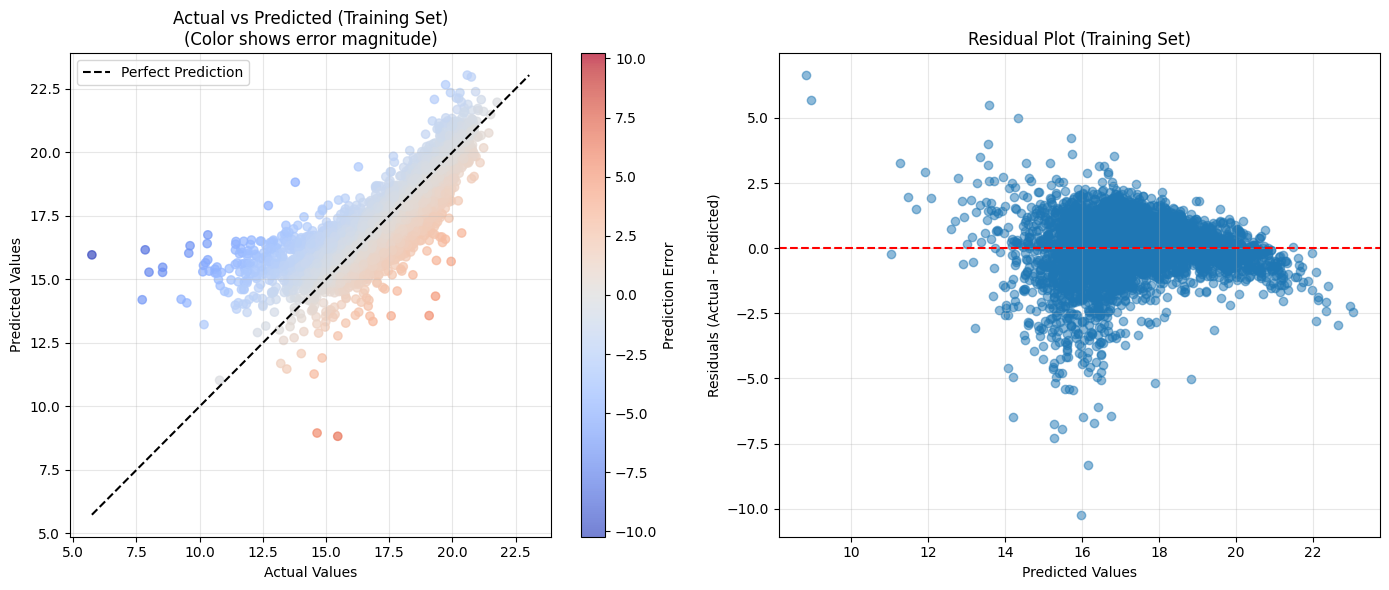

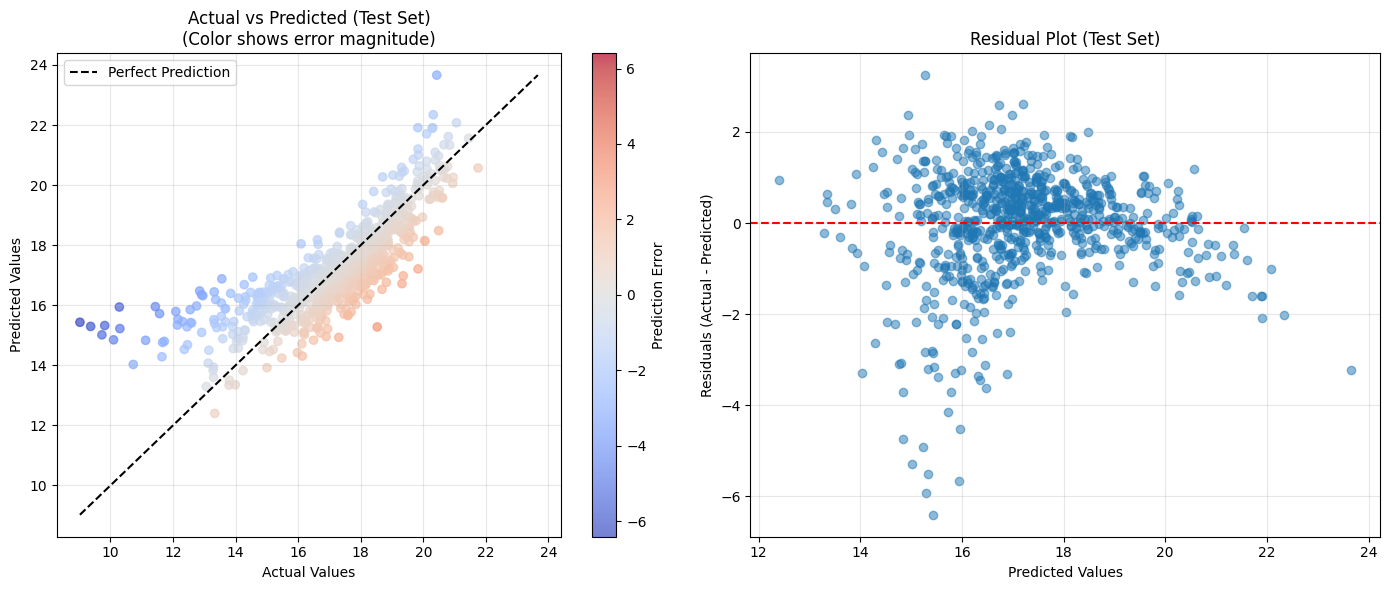

In [38]:
def calculate_regression_metrics(y_true, y_pred):
    """
    Calculate comprehensive regression performance metrics.
    
    Args:
        y_true: Array of true target values
        y_pred: Array of predicted values
        
    Returns:
        Dictionary of calculated metrics
    """
    metrics = {
        'r2': r2_score(y_true, y_pred),
        'mse': mean_squared_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'msle': mean_squared_log_error(y_true, y_pred),
        'mape': np.mean(np.abs((np.exp(y_true) - np.exp(y_pred)) / np.exp(y_true))) * 100,
        'max_error': np.max(np.abs(y_true - y_pred))
    }
    return metrics

def print_metrics_report(metrics_dict, dataset_name="Dataset"):
    """
    Print formatted evaluation metrics in a readable table format.
    
    Args:
        metrics_dict: Dictionary of metric names and values
        dataset_name: Name of the dataset being evaluated
    """
    print(f"\n╔{'═'*35}╗")
    print(f"║ {dataset_name:^33} ║")
    print(f"╠{'═'*15}╦{'═'*19}╣")
    
    # Format and print each metric
    print(f"║ {'R² Score':<13} ║ {metrics_dict['r2']:>17.4f} ║")
    print(f"║ {'MSE':<13} ║ {metrics_dict['mse']:>17.4f} ║")
    print(f"║ {'RMSE':<13} ║ {metrics_dict['rmse']:>17.4f} ║")
    print(f"║ {'MSLE':<13} ║ {metrics_dict['msle']:>17.4f} ║")
    print(f"║ {'MAPE':<13} ║ {metrics_dict['mape']:>16.2f}% ║")
    print(f"║ {'Max Error':<13} ║ {metrics_dict['max_error']:>17.4f} ║")
    print(f"╚{'═'*15}╩{'═'*19}╝")

def plot_regression_diagnostics(y_true, y_pred, title_suffix=""):
    """
    Create a comprehensive diagnostic plot for regression analysis.
    
    Args:
        y_true: Array of true values
        y_pred: Array of predicted values
        title_suffix: Additional context for plot title
    """
    plt.figure(figsize=(14, 6))
    
    # Main plot: Actual vs Predicted with error visualization
    plt.subplot(1, 2, 1)
    error = y_true - y_pred
    scatter = plt.scatter(y_true, y_pred, c=error, cmap='coolwarm', 
                         alpha=0.7, vmin=-np.max(np.abs(error)), 
                         vmax=np.max(np.abs(error)))
    
    # Add reference lines
    max_val = max(np.max(y_true), np.max(y_pred))
    min_val = min(np.min(y_true), np.min(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction')
    
    plt.colorbar(scatter, label='Prediction Error')
    plt.title(f"Actual vs Predicted {title_suffix}\n(Color shows error magnitude)")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Residual plot
    plt.subplot(1, 2, 2)
    plt.scatter(y_pred, error, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f"Residual Plot {title_suffix}")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals (Actual - Predicted)")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def analyze_regression_model(X, y, model=LinearRegression()):
    """
    Complete regression analysis workflow.
    
    Args:
        X: Feature matrix
        y: Target vector
        model: Initialized sklearn regression model
    """
    # Split data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42
    )
    
    # Train model
    model.fit(X_train, y_train)
    
    # Generate predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    
    # Calculate metrics
    train_metrics = calculate_regression_metrics(y_train, train_predictions)
    test_metrics = calculate_regression_metrics(y_test, test_predictions)
    
    # Display results
    print_metrics_report(train_metrics, "Training Set Metrics")
    print_metrics_report(test_metrics, "Test Set Metrics")
    
    # Create diagnostic plots
    plot_regression_diagnostics(y_train, train_predictions, "(Training Set)")
    plot_regression_diagnostics(y_test, test_predictions, "(Test Set)")
    
    return model, train_metrics, test_metrics

# Main execution
if __name__ == "__main__":
    # Load and prepare data (assuming df is defined elsewhere)
    X, y = prepare_features(omdbc)
    
    # Run complete analysis
    trained_model, train_results, test_results = analyze_regression_model(X, y)

## 3. Decision Tree


             TRAINING SET PERFORMANCE             
Metric                                       Value
--------------------------------------------------
R² Score                                    0.8285
MSE                                         0.6051
RMSE                                        0.7779
MSLE                                        0.0024
MAPE                                        99.11%
Max Error                                   5.9019

               TEST SET PERFORMANCE               
Metric                                       Value
--------------------------------------------------
R² Score                                    0.5959
MSE                                         1.5518
RMSE                                        1.2457
MSLE                                        0.0060
MAPE                                       244.09%
Max Error                                   5.7019


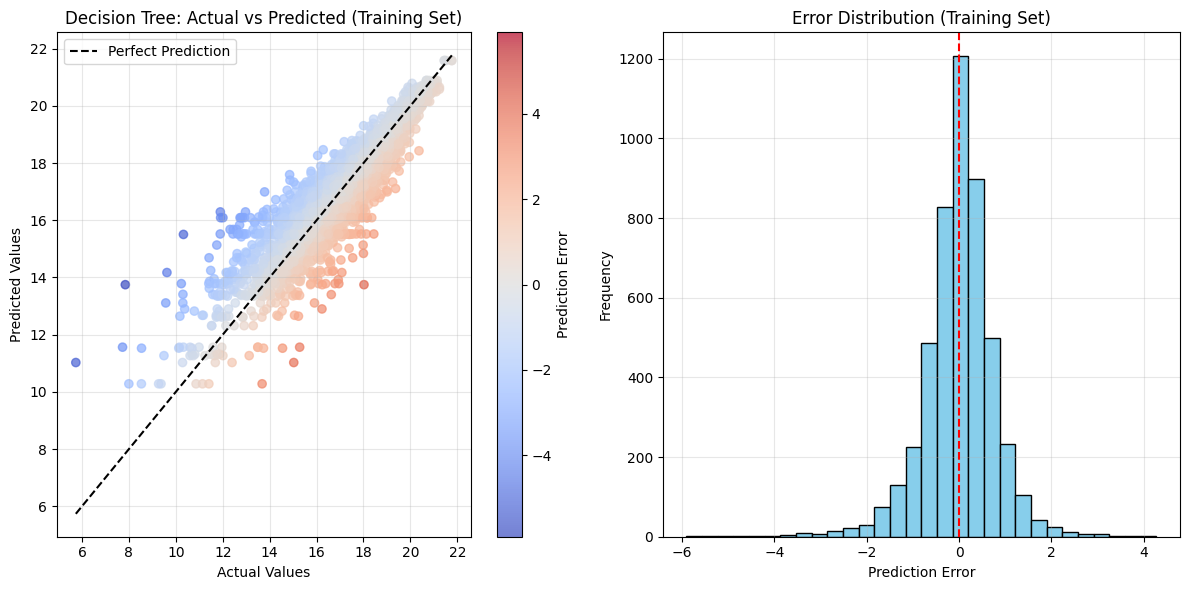

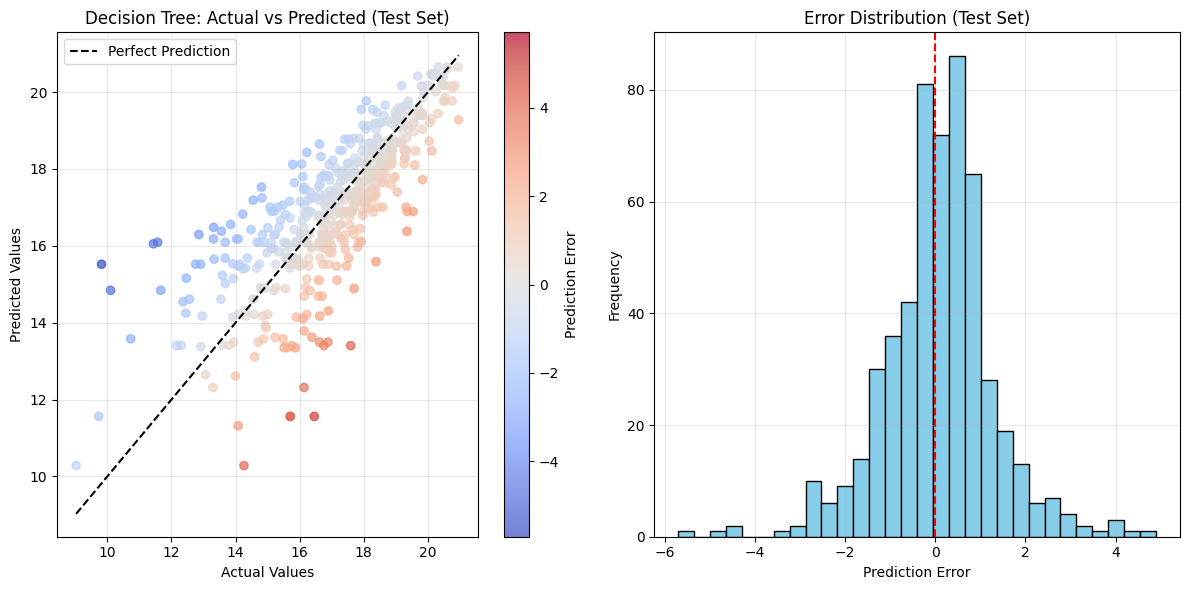

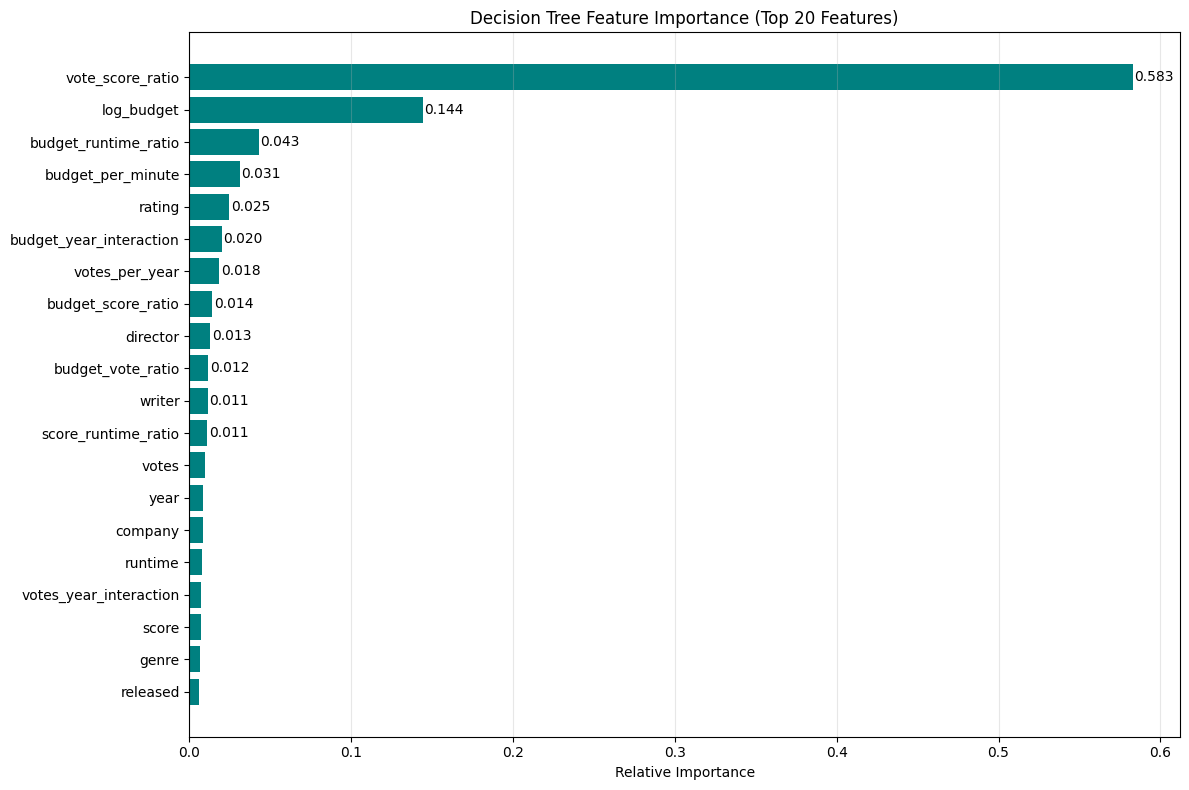

In [40]:
def calculate_tree_metrics(y_true, y_pred):
    """
    Calculate comprehensive regression metrics for decision tree evaluation.
    
    Args:
        y_true: Array of true target values
        y_pred: Array of predicted values
        
    Returns:
        Dictionary of metrics including:
        - r2: Coefficient of determination
        - mse: Mean squared error
        - rmse: Root mean squared error
        - msle: Mean squared logarithmic error
        - mape: Mean absolute percentage error
        - max_error: Worst prediction error
    """
    metrics = {
        'r2': r2_score(y_true, y_pred),
        'mse': mean_squared_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'msle': mean_squared_log_error(y_true, y_pred),
        'mape': np.mean(np.abs((np.exp(y_true) - np.exp(y_pred)) / np.exp(y_true))) * 100,
        'max_error': np.max(np.abs(y_true - y_pred))
    }
    return metrics

def print_tree_metrics(metrics, dataset_name):
    """
    Print formatted evaluation metrics for decision tree in a clear layout.
    
    Args:
        metrics: Dictionary of metric names and values
        dataset_name: Name of the dataset being evaluated
    """
    print(f"\n{'='*50}")
    print(f"{dataset_name.upper():^50}")
    print(f"{'='*50}")
    print(f"{'Metric':<20}{'Value':>30}")
    print(f"{'-'*50}")
    print(f"{'R² Score':<20}{metrics['r2']:>30.4f}")
    print(f"{'MSE':<20}{metrics['mse']:>30.4f}")
    print(f"{'RMSE':<20}{metrics['rmse']:>30.4f}")
    print(f"{'MSLE':<20}{metrics['msle']:>30.4f}")
    print(f"{'MAPE':<20}{metrics['mape']:>29.2f}%")
    print(f"{'Max Error':<20}{metrics['max_error']:>30.4f}")
    print(f"{'='*50}")

def plot_tree_predictions(y_true, y_pred, title_suffix=""):
    """
    Create enhanced visualization of decision tree predictions.
    
    Args:
        y_true: Array of true values
        y_pred: Array of predicted values
        title_suffix: Additional context for plot title
    """
    plt.figure(figsize=(12, 6))
    
    # Calculate error
    error = y_true - y_pred
    
    # Create main plot
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(y_true, y_pred, c=error, 
                         cmap='coolwarm', alpha=0.7,
                         vmin=-np.max(np.abs(error)), 
                         vmax=np.max(np.abs(error)))
    
    # Add reference lines
    max_val = max(np.max(y_true), np.max(y_pred))
    min_val = min(np.min(y_true), np.min(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction')
    
    plt.colorbar(scatter, label='Prediction Error')
    plt.title(f"Decision Tree: Actual vs Predicted {title_suffix}")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Create error distribution plot
    plt.subplot(1, 2, 2)
    plt.hist(error, bins=30, color='skyblue', edgecolor='black')
    plt.axvline(x=0, color='r', linestyle='--')
    plt.title(f"Error Distribution {title_suffix}")
    plt.xlabel("Prediction Error")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_feature_importance(model, feature_names, top_n=20):
    """
    Create enhanced feature importance visualization for decision tree.
    
    Args:
        model: Trained decision tree model
        feature_names: List of feature names
        top_n: Number of top features to display
    """
    importance = model.feature_importances_
    indices = np.argsort(importance)[-top_n:]
    
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(indices)), importance[indices], color='teal', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.title('Decision Tree Feature Importance (Top {} Features)'.format(top_n))
    
    # Add importance values on the bars
    for i, v in enumerate(importance[indices]):
        if v > 0.01:  # Only label significant features
            plt.text(v + 0.001, i, f"{v:.3f}", color='black', va='center')
    
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

def analyze_decision_tree(X, y, test_size=0.1, **tree_params):
    """
    Complete decision tree regression analysis workflow.
    
    Args:
        X: Feature matrix
        y: Target vector
        test_size: Proportion of data for testing
        tree_params: Parameters for DecisionTreeRegressor
        
    Returns:
        Trained model and metrics dictionaries
    """
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    
    # Initialize and train model
    model = DecisionTreeRegressor(random_state=42, **tree_params)
    model.fit(X_train, y_train)
    
    # Generate predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    
    # Calculate metrics
    train_metrics = calculate_tree_metrics(y_train, train_predictions)
    test_metrics = calculate_tree_metrics(y_test, test_predictions)
    
    # Display results
    print_tree_metrics(train_metrics, "Training Set Performance")
    print_tree_metrics(test_metrics, "Test Set Performance")
    
    # Create visualizations
    plot_tree_predictions(y_train, train_predictions, "(Training Set)")
    plot_tree_predictions(y_test, test_predictions, "(Test Set)")
    
    # Plot feature importance if features are named
    if hasattr(X, 'columns'):
        plot_feature_importance(model, X.columns)
    
    return model, train_metrics, test_metrics

# Main execution
if __name__ == "__main__":
    # Load and prepare data (assuming df is defined elsewhere)
    X, y = prepare_features(omdbc)
    
    # Run analysis with custom tree parameters
    tree_params = {
        'max_depth': 10,
        'min_samples_split': 10,
        'min_samples_leaf': 5
    }
    
    model, train_metrics, test_metrics = analyze_decision_tree(
        X, y, test_size=0.1, **tree_params
    )

## 4. Decision Tree Bagging


╔════════════════════════════════════════════════════════════╗
║                  TRAINING SET PERFORMANCE                  ║
╠════════════════════╦═══════════════════════════════════════╣
║ Metric             ║                                 Value ║
╠════════════════════╬═══════════════════════════════════════╣
║ R² Score           ║                                0.8380 ║
║ MSE                ║                                0.5681 ║
║ RMSE               ║                                0.7537 ║
║ MSLE               ║                                0.0023 ║
║ MAPE               ║                               134.18% ║
║ Max Error          ║                                6.6309 ║
║ Mean Absolute Error ║                                0.5187 ║
╚════════════════════╩═══════════════════════════════════════╝

╔════════════════════════════════════════════════════════════╗
║                    TEST SET PERFORMANCE                    ║
╠════════════════════╦══════════════════════════════

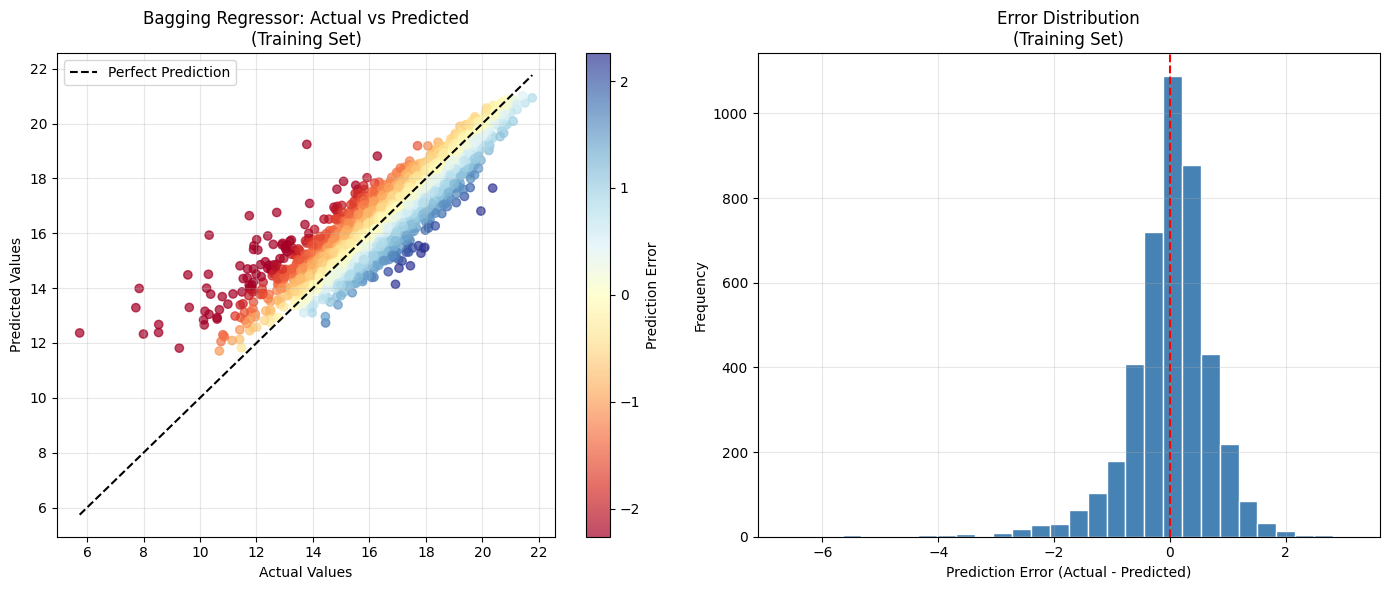

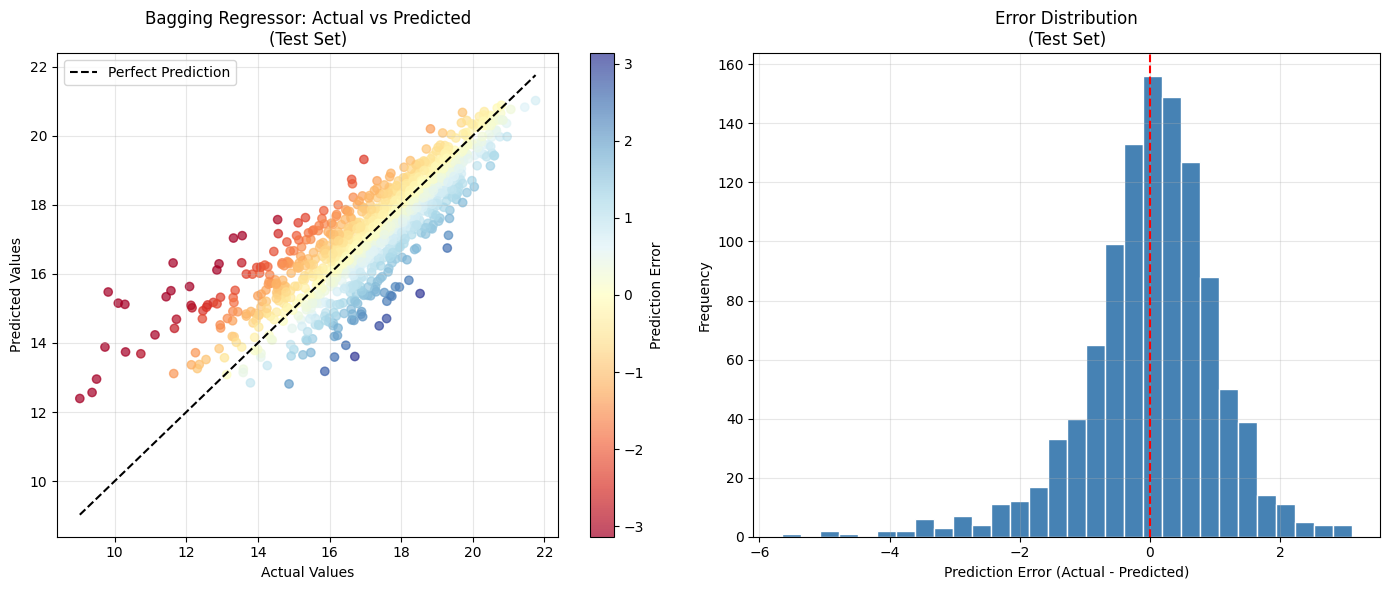

In [42]:
def calculate_bagging_metrics(y_true, y_pred):
    """
    Calculate comprehensive metrics for bagging regressor evaluation.
    
    Args:
        y_true: Array of true target values
        y_pred: Array of predicted values
        
    Returns:
        Dictionary of metrics including:
        - r2: Coefficient of determination
        - mse: Mean squared error
        - rmse: Root mean squared error
        - msle: Mean squared logarithmic error
        - mape: Mean absolute percentage error
        - max_error: Worst prediction error
    """
    metrics = {
        'r2': r2_score(y_true, y_pred),
        'mse': mean_squared_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'msle': mean_squared_log_error(y_true, y_pred),
        'mape': np.mean(np.abs((np.exp(y_true) - np.exp(y_pred)) / np.exp(y_true))) * 100,
        'max_error': np.max(np.abs(y_true - y_pred)),
        'mean_abs_error': np.mean(np.abs(y_true - y_pred))
    }
    return metrics

def print_bagging_metrics(metrics, dataset_name):
    """
    Print formatted evaluation metrics for bagging regressor.
    
    Args:
        metrics: Dictionary of metric names and values
        dataset_name: Name of the dataset being evaluated
    """
    print(f"\n╔{'═'*60}╗")
    print(f"║ {dataset_name.upper():^58} ║")
    print(f"╠{'═'*20}╦{'═'*39}╣")
    print(f"║ {'Metric':<18} ║ {'Value':>37} ║")
    print(f"╠{'═'*20}╬{'═'*39}╣")
    print(f"║ {'R² Score':<18} ║ {metrics['r2']:>37.4f} ║")
    print(f"║ {'MSE':<18} ║ {metrics['mse']:>37.4f} ║")
    print(f"║ {'RMSE':<18} ║ {metrics['rmse']:>37.4f} ║")
    print(f"║ {'MSLE':<18} ║ {metrics['msle']:>37.4f} ║")
    print(f"║ {'MAPE':<18} ║ {metrics['mape']:>36.2f}% ║")
    print(f"║ {'Max Error':<18} ║ {metrics['max_error']:>37.4f} ║")
    print(f"║ {'Mean Absolute Error':<18} ║ {metrics['mean_abs_error']:>37.4f} ║")
    print(f"╚{'═'*20}╩{'═'*39}╝")

def plot_bagging_results(y_true, y_pred, title_suffix=""):
    """
    Create comprehensive visualization for bagging regressor results.
    
    Args:
        y_true: Array of true values
        y_pred: Array of predicted values
        title_suffix: Additional context for plot title
    """
    plt.figure(figsize=(14, 6))
    
    # Calculate error
    error = y_true - y_pred
    
    # Main plot: Actual vs Predicted with error visualization
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(y_true, y_pred, c=error, 
                         cmap='RdYlBu', alpha=0.7,
                         vmin=-3*np.std(error), 
                         vmax=3*np.std(error))
    
    # Add reference lines
    max_val = max(np.max(y_true), np.max(y_pred))
    min_val = min(np.min(y_true), np.min(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', 
             label='Perfect Prediction', linewidth=1.5)
    
    plt.colorbar(scatter, label='Prediction Error')
    plt.title(f"Bagging Regressor: Actual vs Predicted\n{title_suffix}")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Error distribution plot
    plt.subplot(1, 2, 2)
    plt.hist(error, bins=30, color='steelblue', edgecolor='white')
    plt.axvline(x=0, color='r', linestyle='--', linewidth=1.5)
    plt.title(f"Error Distribution\n{title_suffix}")
    plt.xlabel("Prediction Error (Actual - Predicted)")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def analyze_bagging_regressor(X, y, test_size=0.15, 
                            base_estimator_params=None,
                            bagging_params=None):
    """
    Complete bagging regressor analysis workflow.
    
    Args:
        X: Feature matrix
        y: Target vector
        test_size: Proportion of data for testing
        base_estimator_params: Parameters for base DecisionTreeRegressor
        bagging_params: Parameters for BaggingRegressor
        
    Returns:
        Trained model and metrics dictionaries
    """
    # Set default parameters if not provided
    if base_estimator_params is None:
        base_estimator_params = {
            'max_depth': 10,
            'min_samples_split': 10,
            'min_samples_leaf': 5,
            'random_state': 42
        }
    
    if bagging_params is None:
        bagging_params = {
            'n_estimators': 10,
            'random_state': 42
        }
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    
    # Initialize and train model
    base_estimator = DecisionTreeRegressor(**base_estimator_params)
    model = BaggingRegressor(estimator=base_estimator, **bagging_params)
    model.fit(X_train, y_train)
    
    # Generate predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    
    # Calculate metrics
    train_metrics = calculate_bagging_metrics(y_train, train_predictions)
    test_metrics = calculate_bagging_metrics(y_test, test_predictions)
    
    # Display results
    print_bagging_metrics(train_metrics, "Training Set Performance")
    print_bagging_metrics(test_metrics, "Test Set Performance")
    
    # Create visualizations
    plot_bagging_results(y_train, train_predictions, "(Training Set)")
    plot_bagging_results(y_test, test_predictions, "(Test Set)")
    
    return model, train_metrics, test_metrics

# Main execution
if __name__ == "__main__":
    # Load and prepare data (assuming df is defined elsewhere)
    X, y = prepare_features(omdbc)
    
    # Custom parameters for the ensemble
    base_params = {
        'max_depth': 10,
        'min_samples_split': 10,
        'min_samples_leaf': 5,
        'random_state': 42
    }
    
    bagging_params = {
        'n_estimators': 10,
        'random_state': 42
    }
    
    # Run complete analysis
    model, train_metrics, test_metrics = analyze_bagging_regressor(
        X, y,
        test_size=0.2,
        base_estimator_params=base_params,
        bagging_params=bagging_params
    )

## 5. Gradient Boost

Performing grid search to find optimal parameters...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

╔══════════════════════════════════════════════╗
║           GRID SEARCH RESULTS               ║
╠══════════════════════════════════════════════╣
║ Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200} ║
║ Best MSE Score: 1.0711 (negative MSE) ║
╚══════════════════════════════════════════════╝

╔════════════════════════════════════════════════════════════╗
║                  TRAINING SET PERFORMANCE                  ║
╠════════════════════╦═══════════════════════════════════════╣
║ Metric             ║                                 Value ║
╠════════════════════╬═══════════════════════════════════════╣
║ R² Score           ║                                0.8727 ║
║ MSE                ║                                0.4466 ║
║ RMSE               ║                                0.6683 ║
║ MSLE               ║              

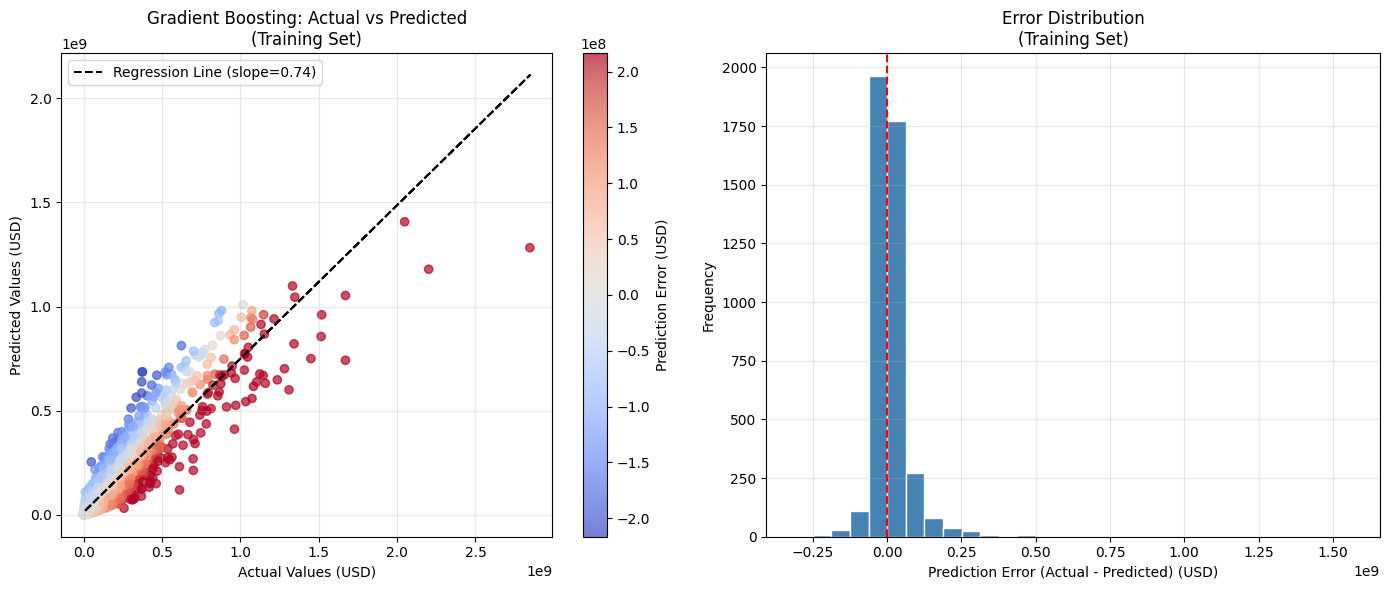

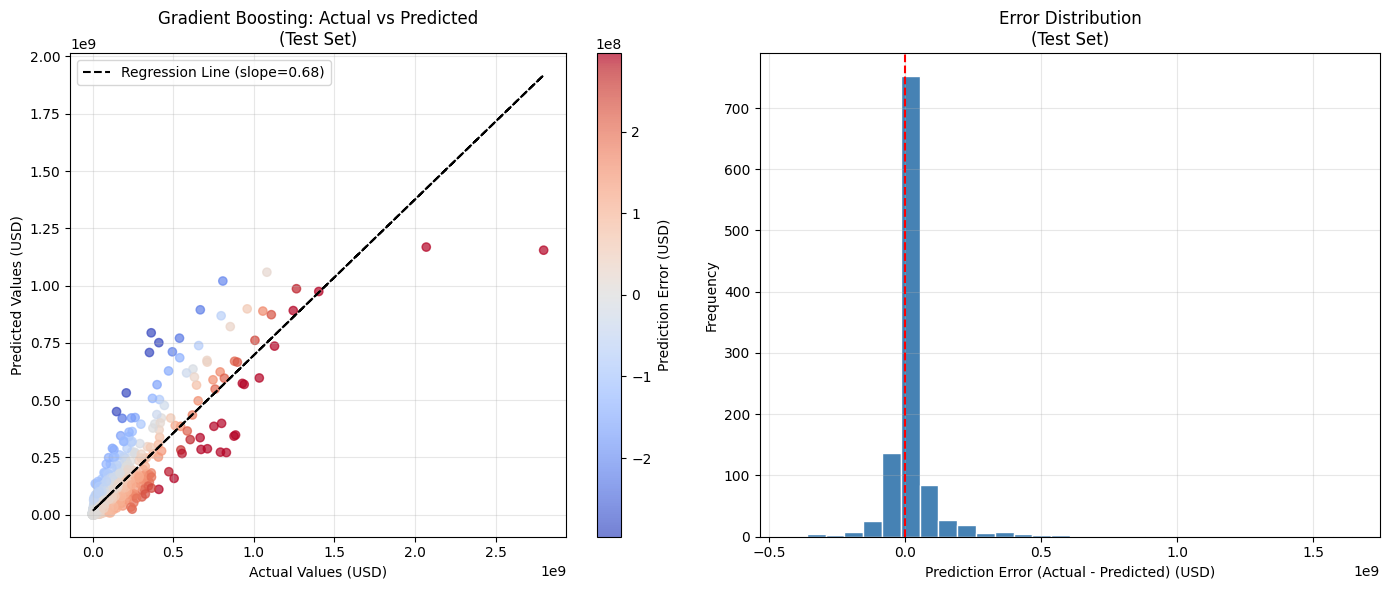

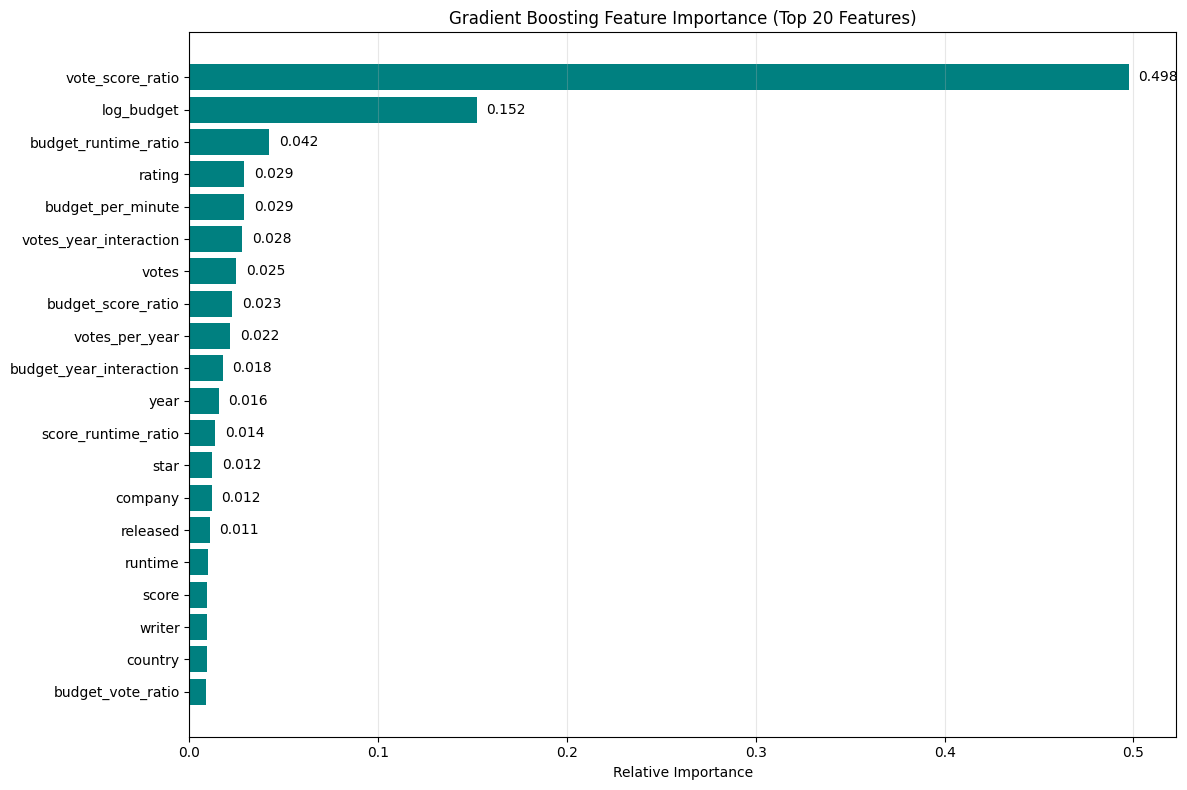

In [ ]:
def calculate_gb_metrics(y_true, y_pred):
    """
    Calculate comprehensive metrics for gradient boosting evaluation.
    
    Args:
        y_true: Array of true target values
        y_pred: Array of predicted values
        
    Returns:
        Dictionary of metrics including:
        - r2: Coefficient of determination
        - mse: Mean squared error
        - rmse: Root mean squared error
        - msle: Mean squared logarithmic error
        - mape: Mean absolute percentage error
        - max_error: Worst prediction error
    """
    metrics = {
        'r2': r2_score(y_true, y_pred),
        'mse': mean_squared_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'msle': mean_squared_log_error(y_true, y_pred),
        'mape': np.mean(np.abs((np.exp(y_true) - np.exp(y_pred)) / np.exp(y_true))) * 100,
        'max_error': np.max(np.abs(y_true - y_pred)),
        'mean_abs_error': np.mean(np.abs(y_true - y_pred))
    }
    return metrics

def print_gb_metrics(metrics, dataset_name):
    """
    Print formatted evaluation metrics for gradient boosting.
    
    Args:
        metrics: Dictionary of metric names and values
        dataset_name: Name of the dataset being evaluated
    """
    print(f"\n╔{'═'*60}╗")
    print(f"║ {dataset_name.upper():^58} ║")
    print(f"╠{'═'*20}╦{'═'*39}╣")
    print(f"║ {'Metric':<18} ║ {'Value':>37} ║")
    print(f"╠{'═'*20}╬{'═'*39}╣")
    print(f"║ {'R² Score':<18} ║ {metrics['r2']:>37.4f} ║")
    print(f"║ {'MSE':<18} ║ {metrics['mse']:>37.4f} ║")
    print(f"║ {'RMSE':<18} ║ {metrics['rmse']:>37.4f} ║")
    print(f"║ {'MSLE':<18} ║ {metrics['msle']:>37.4f} ║")
    print(f"║ {'MAPE':<18} ║ {metrics['mape']:>36.2f}% ║")
    print(f"║ {'Max Error':<18} ║ {metrics['max_error']:>37.4f} ║")
    print(f"║ {'Mean Absolute Error':<18} ║ {metrics['mean_abs_error']:>37.4f} ║")
    print(f"╚{'═'*20}╩{'═'*39}╝")

def plot_gb_predictions(y_true, y_pred, title_suffix=""):
    """
    Create comprehensive visualization for gradient boosting results.
    
    Args:
        y_true: Array of true values
        y_pred: Array of predicted values
        title_suffix: Additional context for plot title
    """
    plt.figure(figsize=(14, 6))
    
    # Convert log-transformed values back to original scale
    y_true_orig = np.exp(y_true) - 1
    y_pred_orig = np.exp(y_pred) - 1
    error = y_true_orig - y_pred_orig
    
    # Main plot: Actual vs Predicted with error visualization
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(y_true_orig, y_pred_orig, c=error, 
                         cmap='coolwarm', alpha=0.7,
                         vmin=-3*np.std(error), 
                         vmax=3*np.std(error))
    
    # Add regression line
    z = np.polyfit(y_true_orig, y_pred_orig, 1)
    p = np.poly1d(z)
    plt.plot(y_true_orig, p(y_true_orig), 'k--', 
             label=f'Regression Line (slope={z[0]:.2f})', linewidth=1.5)
    
    plt.colorbar(scatter, label='Prediction Error (USD)')
    plt.title(f"Gradient Boosting: Actual vs Predicted\n{title_suffix}")
    plt.xlabel("Actual Values (USD)")
    plt.ylabel("Predicted Values (USD)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Error distribution plot
    plt.subplot(1, 2, 2)
    plt.hist(error, bins=30, color='steelblue', edgecolor='white')
    plt.axvline(x=0, color='r', linestyle='--', linewidth=1.5)
    plt.title(f"Error Distribution\n{title_suffix}")
    plt.xlabel("Prediction Error (Actual - Predicted) (USD)")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_gb_feature_importance(model, feature_names, top_n=20):
    """
    Create enhanced feature importance visualization for gradient boosting.
    
    Args:
        model: Trained gradient boosting model
        feature_names: List of feature names
        top_n: Number of top features to display
    """
    importance = model.feature_importances_
    indices = np.argsort(importance)[-top_n:]
    
    plt.figure(figsize=(12, 8))
    bars = plt.barh(range(len(indices)), importance[indices], 
                   color='teal', align='center')
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        if width > 0.01:  # Only label significant features
            plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{width:.3f}', 
                    va='center', ha='left')
    
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.title(f'Gradient Boosting Feature Importance (Top {top_n} Features)')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

def analyze_gradient_boosting(X, y, test_size=0.2, param_grid=None):
    """
    Complete gradient boosting analysis with grid search workflow.
    
    Args:
        X: Feature matrix
        y: Target vector
        test_size: Proportion of data for testing
        param_grid: Parameters for GridSearchCV
        
    Returns:
        Best trained model and metrics dictionaries
    """
    # Set default parameter grid if not provided
    if param_grid is None:
        param_grid = {
            "n_estimators": [100, 500],
            "max_depth": [3, 6],
            "learning_rate": [0.05, 0.1],
        }
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    
    # Perform grid search
    print("Performing grid search to find optimal parameters...")
    grid_search = GridSearchCV(
        estimator=GradientBoostingRegressor(loss="squared_error", random_state=42),
        param_grid=param_grid,
        cv=5,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    
    # Print best parameters
    print("\n╔══════════════════════════════════════════════╗")
    print("║           GRID SEARCH RESULTS               ║")
    print("╠══════════════════════════════════════════════╣")
    print(f"║ Best Parameters: {str(grid_search.best_params_):<25} ║")
    print(f"║ Best MSE Score: {-grid_search.best_score_:.4f} (negative MSE) ║")
    print("╚══════════════════════════════════════════════╝")
    
    # Train best model
    best_model = grid_search.best_estimator_
    best_model.fit(X_train, y_train)
    
    # Generate predictions
    train_predictions = best_model.predict(X_train)
    test_predictions = best_model.predict(X_test)
    
    # Calculate metrics
    train_metrics = calculate_gb_metrics(y_train, train_predictions)
    test_metrics = calculate_gb_metrics(y_test, test_predictions)
    
    # Display results
    print_gb_metrics(train_metrics, "Training Set Performance")
    print_gb_metrics(test_metrics, "Test Set Performance")
    
    # Create visualizations
    plot_gb_predictions(y_train, train_predictions, "(Training Set)")
    plot_gb_predictions(y_test, test_predictions, "(Test Set)")
    
    # Plot feature importance if features are named
    if hasattr(X, 'columns'):
        plot_gb_feature_importance(best_model, X.columns)
    
    return best_model, train_metrics, test_metrics

# Main execution
if __name__ == "__main__":
    # Load and prepare data (assuming df is defined elsewhere)
    X, y = prepare_features(omdbc)
    
    # Custom parameter grid for tuning
    custom_param_grid = {
        "n_estimators": [100, 200, 500],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1],
        "min_samples_split": [2, 5, 10]
    }
    
    # Run complete analysis
    best_model, train_metrics, test_metrics = analyze_gradient_boosting(
        X, y,
        test_size=0.15,
        param_grid=custom_param_grid
    )

## 6. Random Forest

Training Random Forest model...

================ RANDOM FOREST PERFORMANCE =================
                  TRAINING SET PERFORMANCE                  
Metric                                                 Value
------------------------------------------------------------
R² Score                                              0.8806
Mean Squared Error                                    0.4173
Root MSE                                              0.6460
Mean Squared Log Error                                0.0018
Mean Absolute % Error                                138.30%
Max Error                                             7.8135
Mean Absolute Error                                   0.4386

================ RANDOM FOREST PERFORMANCE =================
                    TEST SET PERFORMANCE                    
Metric                                                 Value
------------------------------------------------------------
R² Score                                           

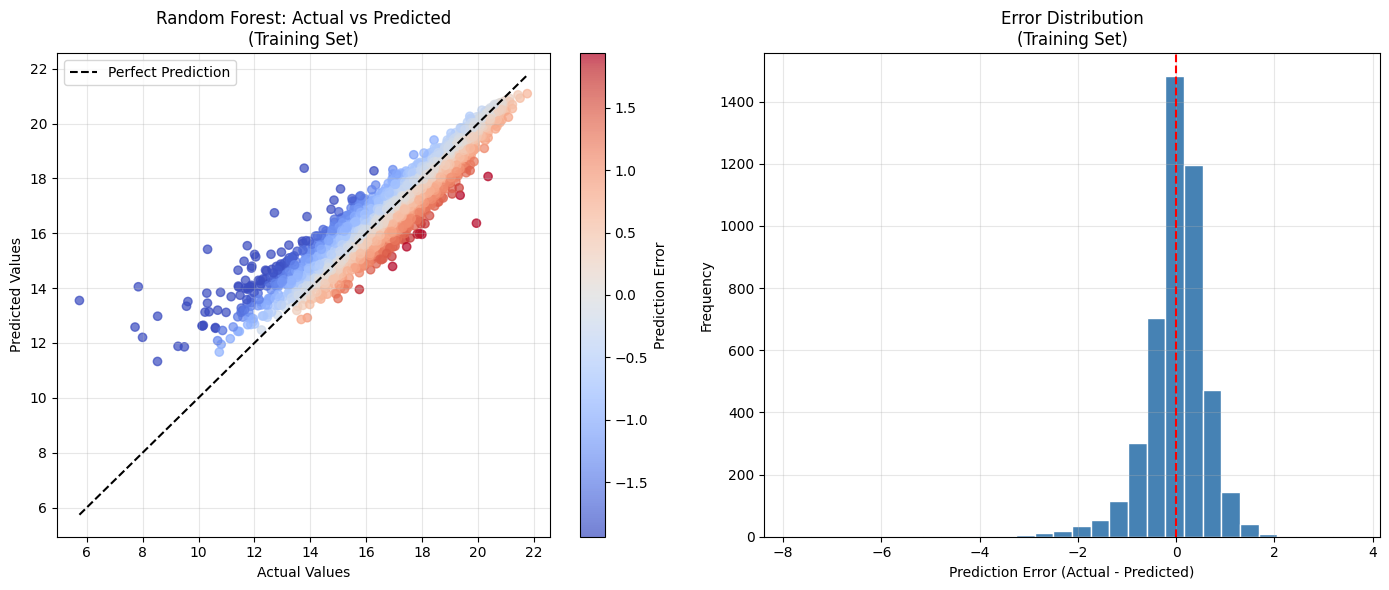

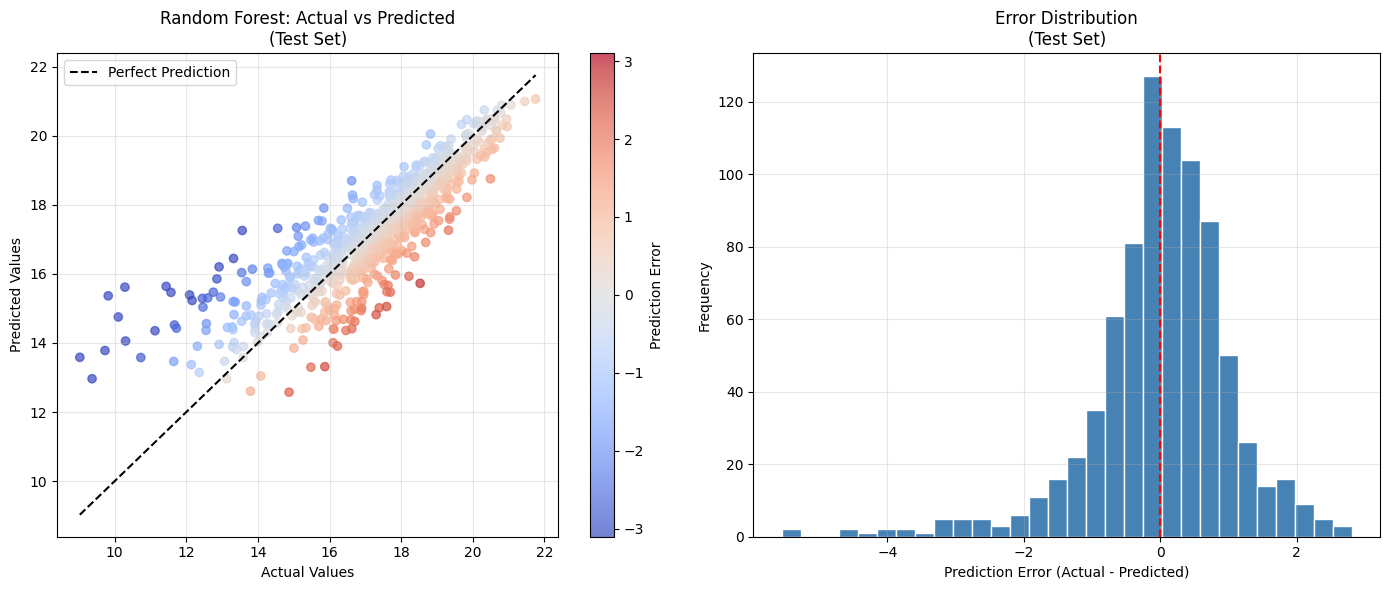

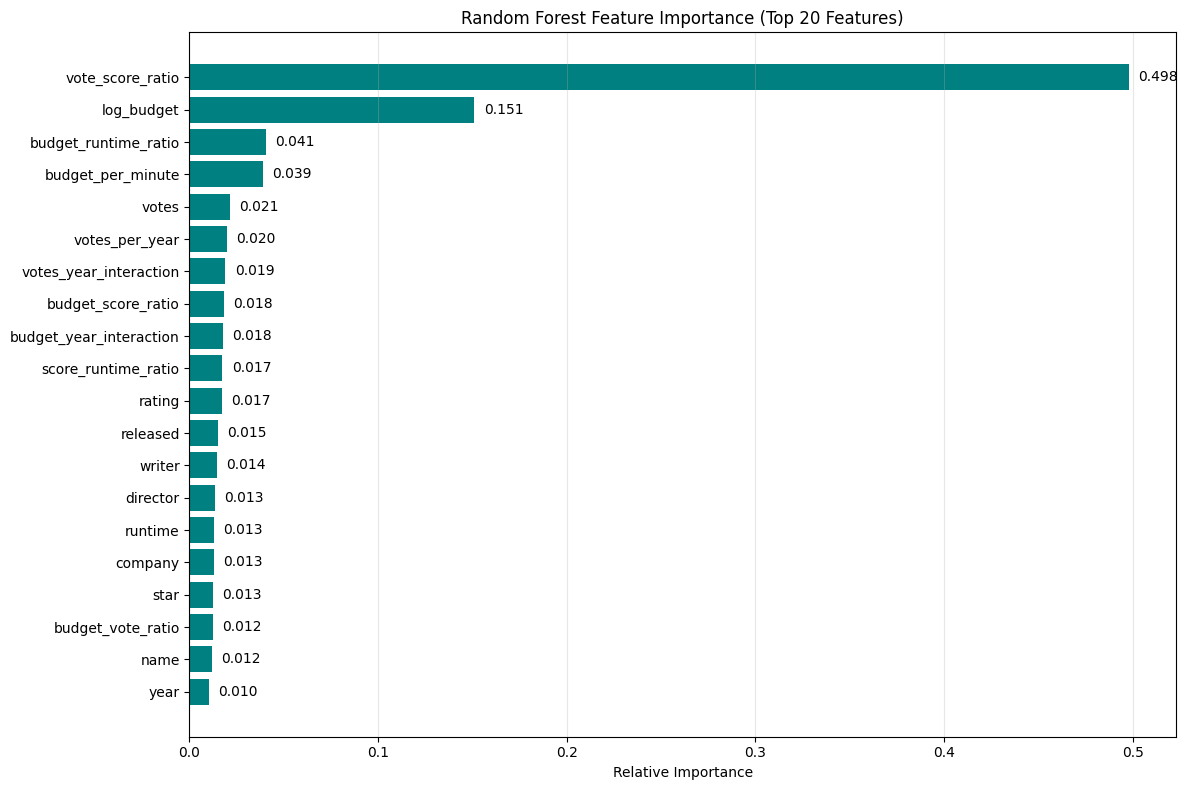

In [45]:
def calculate_rf_metrics(y_true, y_pred):
    """
    Calculate comprehensive metrics for Random Forest evaluation.
    
    Args:
        y_true: True target values
        y_pred: Predicted values
        
    Returns:
        Dictionary of evaluation metrics
    """
    metrics = {
        'r2': r2_score(y_true, y_pred),
        'mse': mean_squared_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'msle': mean_squared_log_error(y_true, y_pred),
        'mape': np.mean(np.abs((np.exp(y_true) - np.exp(y_pred)) / np.exp(y_true))) * 100,
        'max_error': np.max(np.abs(y_true - y_pred)),
        'mean_abs_error': np.mean(np.abs(y_true - y_pred))
    }
    return metrics

def print_rf_metrics(metrics, dataset_name):
    """
    Print formatted evaluation metrics for Random Forest.
    
    Args:
        metrics: Dictionary of metrics
        dataset_name: Name of dataset being evaluated
    """
    print(f"\n{'='*60}")
    print(f"{' RANDOM FOREST PERFORMANCE ':=^60}")
    print(f"{dataset_name.upper():^60}")
    print(f"{'='*60}")
    print(f"{'Metric':<25}{'Value':>35}")
    print(f"{'-'*60}")
    print(f"{'R² Score':<25}{metrics['r2']:>35.4f}")
    print(f"{'Mean Squared Error':<25}{metrics['mse']:>35.4f}")
    print(f"{'Root MSE':<25}{metrics['rmse']:>35.4f}")
    print(f"{'Mean Squared Log Error':<25}{metrics['msle']:>35.4f}")
    print(f"{'Mean Absolute % Error':<25}{metrics['mape']:>34.2f}%")
    print(f"{'Max Error':<25}{metrics['max_error']:>35.4f}")
    print(f"{'Mean Absolute Error':<25}{metrics['mean_abs_error']:>35.4f}")
    print(f"{'='*60}")

def plot_rf_predictions(y_true, y_pred, title_suffix=""):
    """
    Visualize Random Forest predictions with enhanced diagnostics.
    
    Args:
        y_true: True values
        y_pred: Predicted values
        title_suffix: Additional plot title context
    """
    plt.figure(figsize=(14, 6))
    
    # Calculate error
    error = y_true - y_pred
    
    # Main plot: Actual vs Predicted
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(y_true, y_pred, c=error, 
                        cmap='coolwarm', alpha=0.7,
                        vmin=-3*np.std(error), 
                        vmax=3*np.std(error))
    
    # Add reference lines
    max_val = max(np.max(y_true), np.max(y_pred))
    min_val = min(np.min(y_true), np.min(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', 
            label='Perfect Prediction', linewidth=1.5)
    
    plt.colorbar(scatter, label='Prediction Error')
    plt.title(f"Random Forest: Actual vs Predicted\n{title_suffix}")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Error distribution plot
    plt.subplot(1, 2, 2)
    plt.hist(error, bins=30, color='steelblue', edgecolor='white')
    plt.axvline(x=0, color='r', linestyle='--', linewidth=1.5)
    plt.title(f"Error Distribution\n{title_suffix}")
    plt.xlabel("Prediction Error (Actual - Predicted)")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_rf_feature_importance(model, feature_names, top_n=20):
    """
    Visualize Random Forest feature importance.
    
    Args:
        model: Trained Random Forest model
        feature_names: List of feature names
        top_n: Number of top features to display
    """
    importance = model.feature_importances_
    indices = np.argsort(importance)[-top_n:]
    
    plt.figure(figsize=(12, 8))
    bars = plt.barh(range(len(indices)), importance[indices], 
                   color='teal', align='center')
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        if width > 0.01:  # Only label significant features
            plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
                   f'{width:.3f}', 
                   va='center', ha='left')
    
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.title(f'Random Forest Feature Importance (Top {top_n} Features)')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

def analyze_random_forest(X, y, test_size=0.15, rf_params=None):
    """
    Complete Random Forest analysis workflow.
    
    Args:
        X: Feature matrix
        y: Target vector
        test_size: Proportion for test split
        rf_params: Parameters for RandomForestRegressor
        
    Returns:
        Trained model and metrics dictionaries
    """
    # Set default parameters if not provided
    if rf_params is None:
        rf_params = {
            'n_estimators': 100,
            'max_depth': 10,
            'min_samples_split': 10,
            'min_samples_leaf': 5,
            'random_state': 42,
            'n_jobs': -1  # Use all available cores
        }
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    
    # Initialize and train model
    print("Training Random Forest model...")
    model = RandomForestRegressor(**rf_params)
    model.fit(X_train, y_train)
    
    # Generate predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    
    # Calculate metrics
    train_metrics = calculate_rf_metrics(y_train, train_predictions)
    test_metrics = calculate_rf_metrics(y_test, test_predictions)
    
    # Display results
    print_rf_metrics(train_metrics, "Training Set Performance")
    print_rf_metrics(test_metrics, "Test Set Performance")
    
    # Create visualizations
    plot_rf_predictions(y_train, train_predictions, "(Training Set)")
    plot_rf_predictions(y_test, test_predictions, "(Test Set)")
    
    # Plot feature importance if features are named
    if hasattr(X, 'columns'):
        plot_rf_feature_importance(model, X.columns)
    
    return model, train_metrics, test_metrics

# Main execution
if __name__ == "__main__":
    # Load and prepare data
    X, y = prepare_features(omdbc)
    
    # Custom Random Forest parameters
    custom_rf_params = {
        'n_estimators': 150,
        'max_depth': 12,
        'min_samples_split': 8,
        'min_samples_leaf': 4,
        'random_state': 42,
        'n_jobs': -1
    }
    
    # Run complete analysis
    rf_model, train_results, test_results = analyze_random_forest(
        X, y,
        test_size=0.15,
        rf_params=custom_rf_params
    )

## 7. XGBoost


Performing hyperparameter tuning with GridSearchCV...
Fitting 5 folds for each of 729 candidates, totalling 3645 fits

╔══════════════════════════════════════════════╗
║         HYPERPARAMETER TUNING RESULTS      ║
╠══════════════════════════════════════════════╣
║ Best Parameters: {'colsample_bytree': 0.9, 'gamma': 0.2, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.9} ║
║ Best R² Score: 0.7024 ║
╚══════════════════════════════════════════════╝

============== XGBOOST REGRESSION PERFORMANCE ==============
                  TRAINING SET PERFORMANCE                  
Metric                                                 Value
------------------------------------------------------------
R² Score                                              0.8249
Mean Squared Error                                    0.6123
Root MSE                                              0.7825
Mean Squared Log Error                                0.0024
Mean Absolute % Error           

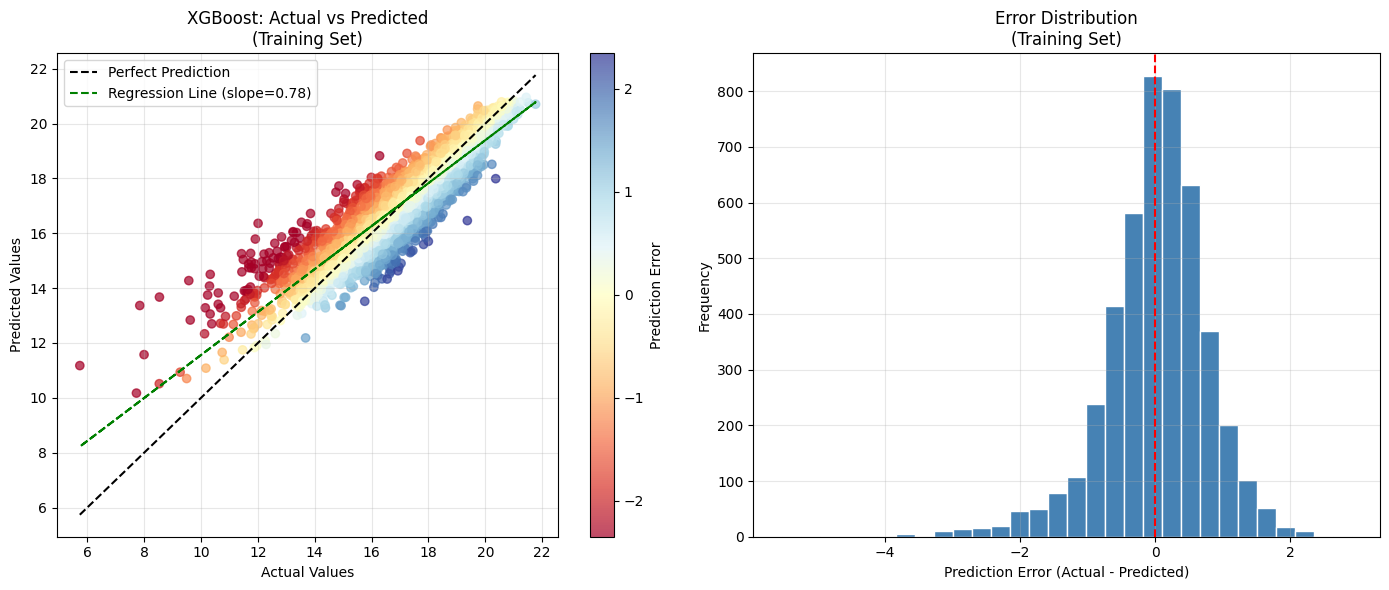

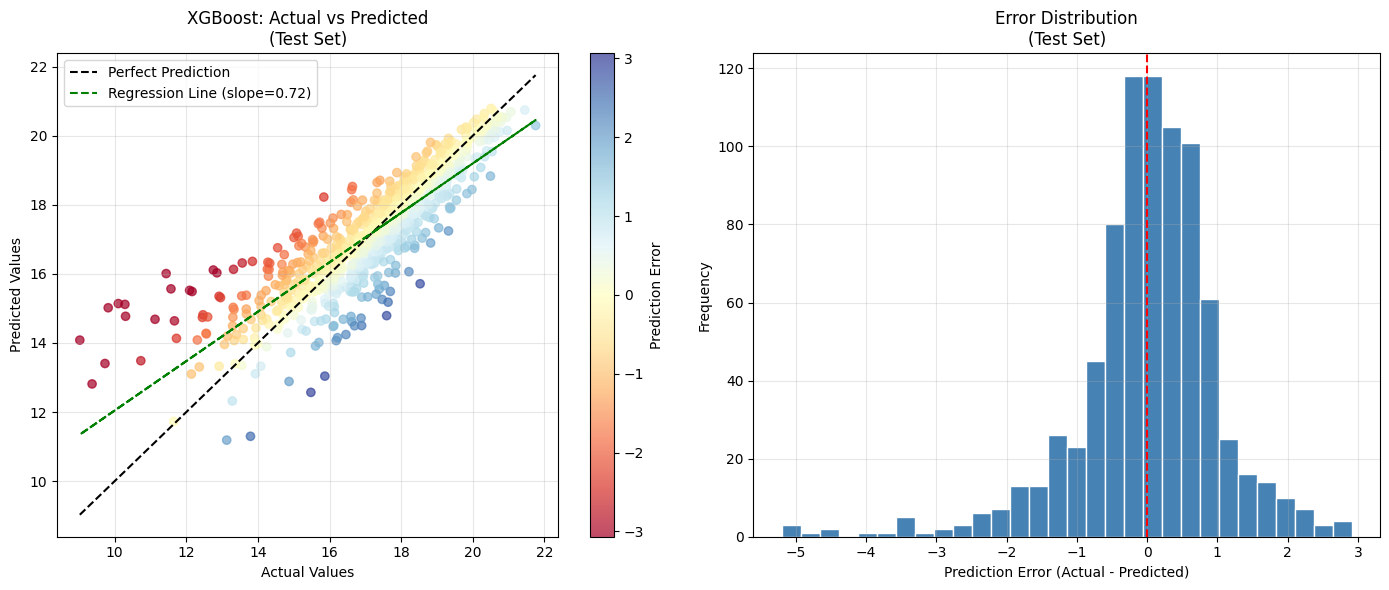

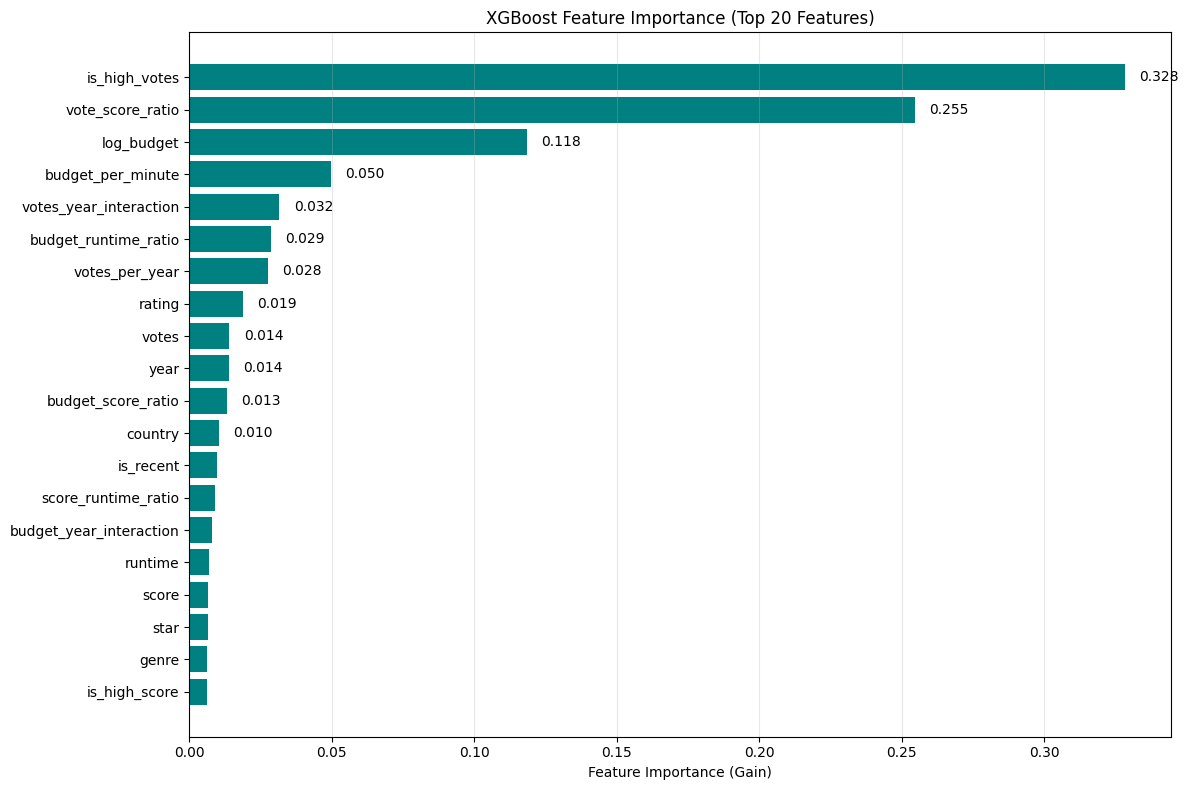

In [47]:
def calculate_xgb_metrics(y_true, y_pred):
    """
    Calculate comprehensive metrics for XGBoost evaluation.
    
    Args:
        y_true: True target values
        y_pred: Predicted values
        
    Returns:
        Dictionary of evaluation metrics
    """
    metrics = {
        'r2': r2_score(y_true, y_pred),
        'mse': mean_squared_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'msle': mean_squared_log_error(y_true, y_pred),
        'mape': np.mean(np.abs((np.exp(y_true) - np.exp(y_pred)) / np.exp(y_true))) * 100,
        'max_error': np.max(np.abs(y_true - y_pred)),
        'mean_abs_error': np.mean(np.abs(y_true - y_pred))
    }
    return metrics

def print_xgb_metrics(metrics, dataset_name):
    """
    Print formatted evaluation metrics for XGBoost.
    
    Args:
        metrics: Dictionary of metrics
        dataset_name: Name of dataset being evaluated
    """
    print(f"\n{'='*60}")
    print(f"{' XGBOOST REGRESSION PERFORMANCE ':=^60}")
    print(f"{dataset_name.upper():^60}")
    print(f"{'='*60}")
    print(f"{'Metric':<25}{'Value':>35}")
    print(f"{'-'*60}")
    print(f"{'R² Score':<25}{metrics['r2']:>35.4f}")
    print(f"{'Mean Squared Error':<25}{metrics['mse']:>35.4f}")
    print(f"{'Root MSE':<25}{metrics['rmse']:>35.4f}")
    print(f"{'Mean Squared Log Error':<25}{metrics['msle']:>35.4f}")
    print(f"{'Mean Absolute % Error':<25}{metrics['mape']:>34.2f}%")
    print(f"{'Max Error':<25}{metrics['max_error']:>35.4f}")
    print(f"{'Mean Absolute Error':<25}{metrics['mean_abs_error']:>35.4f}")
    print(f"{'='*60}")

def plot_xgb_predictions(y_true, y_pred, title_suffix=""):
    """
    Visualize XGBoost predictions with enhanced diagnostics.
    
    Args:
        y_true: True values
        y_pred: Predicted values
        title_suffix: Additional plot title context
    """
    plt.figure(figsize=(14, 6))
    
    # Calculate error
    error = y_true - y_pred
    
    # Main plot: Actual vs Predicted
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(y_true, y_pred, c=error, 
                        cmap='RdYlBu', alpha=0.7,
                        vmin=-3*np.std(error), 
                        vmax=3*np.std(error))
    
    # Add reference lines
    max_val = max(np.max(y_true), np.max(y_pred))
    min_val = min(np.min(y_true), np.min(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', 
            label='Perfect Prediction', linewidth=1.5)
    
    # Add regression line
    coef = np.polyfit(y_true, y_pred, 1)
    poly1d_fn = np.poly1d(coef) 
    plt.plot(y_true, poly1d_fn(y_true), 'g--', 
            label=f'Regression Line (slope={coef[0]:.2f})')
    
    plt.colorbar(scatter, label='Prediction Error')
    plt.title(f"XGBoost: Actual vs Predicted\n{title_suffix}")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Error distribution plot
    plt.subplot(1, 2, 2)
    plt.hist(error, bins=30, color='steelblue', edgecolor='white')
    plt.axvline(x=0, color='r', linestyle='--', linewidth=1.5)
    plt.title(f"Error Distribution\n{title_suffix}")
    plt.xlabel("Prediction Error (Actual - Predicted)")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_xgb_feature_importance(model, feature_names, top_n=20):
    """
    Visualize XGBoost feature importance.
    
    Args:
        model: Trained XGBoost model
        feature_names: List of feature names
        top_n: Number of top features to display
    """
    importance = model.feature_importances_
    indices = np.argsort(importance)[-top_n:]
    
    plt.figure(figsize=(12, 8))
    bars = plt.barh(range(len(indices)), importance[indices], 
                   color='teal', align='center')
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        if width > 0.01:  # Only label significant features
            plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
                   f'{width:.3f}', 
                   va='center', ha='left')
    
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Feature Importance (Gain)')
    plt.title(f'XGBoost Feature Importance (Top {top_n} Features)')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

def analyze_xgboost(X, y, test_size=0.15, param_grid=None):
    """
    Complete XGBoost analysis with hyperparameter tuning workflow.
    
    Args:
        X: Feature matrix
        y: Target vector
        test_size: Proportion for test split
        param_grid: Parameters for GridSearchCV
        
    Returns:
        Best trained model and metrics dictionaries
    """
    # Set default parameter grid if not provided
    if param_grid is None:
        param_grid = {
            "n_estimators": [100, 500],
            "max_depth": [3, 6],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    
    # Perform grid search
    print("\nPerforming hyperparameter tuning with GridSearchCV...")
    grid_search = GridSearchCV(
        estimator=xgb.XGBRegressor(objective="reg:squarederror", 
                                 random_state=42,
                                 n_jobs=-1),
        param_grid=param_grid,
        cv=5,
        scoring="r2",
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    
    # Print best parameters
    print("\n╔══════════════════════════════════════════════╗")
    print("║         HYPERPARAMETER TUNING RESULTS      ║")
    print("╠══════════════════════════════════════════════╣")
    print(f"║ Best Parameters: {str(grid_search.best_params_):<25} ║")
    print(f"║ Best R² Score: {grid_search.best_score_:.4f} ║")
    print("╚══════════════════════════════════════════════╝")
    
    # Train best model
    best_model = grid_search.best_estimator_
    best_model.fit(X_train, y_train)
    
    # Generate predictions
    train_predictions = best_model.predict(X_train)
    test_predictions = best_model.predict(X_test)
    
    # Calculate metrics
    train_metrics = calculate_xgb_metrics(y_train, train_predictions)
    test_metrics = calculate_xgb_metrics(y_test, test_predictions)
    
    # Display results
    print_xgb_metrics(train_metrics, "Training Set Performance")
    print_xgb_metrics(test_metrics, "Test Set Performance")
    
    # Create visualizations
    plot_xgb_predictions(y_train, train_predictions, "(Training Set)")
    plot_xgb_predictions(y_test, test_predictions, "(Test Set)")
    
    # Plot feature importance if features are named
    if hasattr(X, 'columns'):
        plot_xgb_feature_importance(best_model, X.columns)
    
    return best_model, train_metrics, test_metrics

# Main execution
if __name__ == "__main__":
    # Load and prepare data
    X, y = prepare_features(omdbc)
    
    # Custom parameter grid for tuning
    custom_param_grid = {
        "n_estimators": [100, 200, 500],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1],
        "gamma": [0, 0.1, 0.2],
        "subsample": [0.8, 0.9, 1.0],
        "colsample_bytree": [0.8, 0.9, 1.0]
    }
    
    # Run complete analysis
    xgb_model, train_results, test_results = analyze_xgboost(
        X, y,
        test_size=0.15,
        param_grid=custom_param_grid
    )